In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
import numpy as np

In [5]:
#loading data

races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')
drivers = pd.read_csv('dataset/drivers.csv')
constructors = pd.read_csv('dataset/constructors.csv')
circuits = pd.read_csv('dataset/circuits.csv')
lap = pd.read_csv('dataset/lap_times.csv')
seasons = pd.read_csv('dataset/seasons.csv')
sprint_results = pd.read_csv('dataset/sprint_results.csv')
status = pd.read_csv('dataset/status.csv')
pit_stops = pd.read_csv('dataset/pit_stops.csv')

Research Objective:
    
To examine how pit frequency and timing impacts race performance and to identify common strategy patterns using statistical and machine learning approaches.

Research Problem:

Pit Stop Strategy is a key determinant in Formula 1 race outcomes, yet its quantifable relationship to finishing position remains underexplored in public datasets

In [6]:
#exploratory data analysis

for name, df in [('races', races),('results',results),('drivers',drivers),('constrictors', constructors),('pit_stops', pit_stops)]:
    print(f"{name}:{df.shape}")
    display(df.head(2))
    print(df.info(),"\n")

races:(1125, 18)


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       1125 non-null   int64 
 1   year         1125 non-null   int64 
 2   round        1125 non-null   int64 
 3   circuitId    1125 non-null   int64 
 4   name         1125 non-null   object
 5   date         1125 non-null   object
 6   time         1125 non-null   object
 7   url          1125 non-null   object
 8   fp1_date     1125 non-null   object
 9   fp1_time     1125 non-null   object
 10  fp2_date     1125 non-null   object
 11  fp2_time     1125 non-null   object
 12  fp3_date     1125 non-null   object
 13  fp3_time     1125 non-null   object
 14  quali_date   1125 non-null   object
 15  quali_time   1125 non-null   object
 16  sprint_date  1125 non-null   object
 17  sprint_time  1125 non-null   object
dtypes: int64(4), object(14)
memory usage: 158.3+ KB
None 

results:(2675

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 
 17  statusId    

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   driverId     861 non-null    int64 
 1   driverRef    861 non-null    object
 2   number       861 non-null    object
 3   code         861 non-null    object
 4   forename     861 non-null    object
 5   surname      861 non-null    object
 6   dob          861 non-null    object
 7   nationality  861 non-null    object
 8   url          861 non-null    object
dtypes: int64(1), object(8)
memory usage: 60.7+ KB
None 

constrictors:(212, 5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   212 non-null    int64 
 1   constructorRef  212 non-null    object
 2   name            212 non-null    object
 3   nationality     212 non-null    object
 4   url             212 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.4+ KB
None 

pit_stops:(11371, 7)


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11371 entries, 0 to 11370
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        11371 non-null  int64 
 1   driverId      11371 non-null  int64 
 2   stop          11371 non-null  int64 
 3   lap           11371 non-null  int64 
 4   time          11371 non-null  object
 5   duration      11371 non-null  object
 6   milliseconds  11371 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 622.0+ KB
None 



In [7]:
#Cleaning data

#Handling missing values
pit_stops = pit_stops.dropna(subset=['milliseconds'])
results = results.dropna(subset=['positionOrder'])

In [8]:
#converting data type to int

pit_stops['milliseconds'] = pit_stops['milliseconds'].astype(int)
pit_stops['lap'] = pit_stops['lap'].astype(int)

In [9]:
#filtering data from 2012 onwards as the pit stop data is readily available from 2012

races = races[races['year'] >= 2012]

In [10]:
#grouping the pit stop data per driver per race

pit_summary = (pit_stops.groupby(['raceId','driverId'])
              .agg(
              pit_count=('stop','count'),
              total_pit_time=('milliseconds', 'sum'),
              avg_pit_time=('milliseconds', 'mean'),
              first_stop_lap=('lap','min'),
              last_stop_lap=('lap','max')
              )
              .reset_index()
              )

pit_summary.head(3)

,raceId,driverId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap
0,841,1,2,46426,23213.0,16,36
1,841,2,2,48092,24046.0,15,30
2,841,3,1,23716,23716.0,16,16


In [11]:
#Ensuring that the drivers name is part of the merged table

drivers_short = drivers[['driverId', 'forename','surname']]

pit_summary = pit_summary.merge(drivers_short, on = 'driverId', how ='left')

pit_summary.head(5)

,raceId,driverId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,forename,surname
0,841,1,2,46426,23213.0,16,36,Lewis,Hamilton
1,841,2,2,48092,24046.0,15,30,Nick,Heidfeld
2,841,3,1,23716,23716.0,16,16,Nico,Rosberg
3,841,4,3,72165,24055.0,12,42,Fernando,Alonso
4,841,5,1,24865,24865.0,17,17,Heikki,Kovalainen


In [12]:
#Merge with race results

merged = (
    results
    .merge(pit_summary, on=['raceId', 'driverId'], how='left')
    .merge(races[['raceId', 'year', 'name']], on='raceId', how='left')
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')
    .merge(constructors[['constructorId', 'name']], on='constructorId', how='left', suffixes=('_team', '_driver'))
)

merged.tail(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
26756,26762,1144,822,15,77,9,\N,R,18,0.0,...,41144.0,6.0,6.0,Valtteri,Bottas,2024.0,Abu Dhabi Grand Prix,Valtteri,Bottas,Sauber
26757,26763,1144,861,3,43,20,\N,R,19,0.0,...,24941.0,3.0,3.0,Franco,Colapinto,2024.0,Abu Dhabi Grand Prix,Franco,Colapinto,Williams
26758,26764,1144,815,9,11,10,\N,R,20,0.0,...,NaN,NaN,NaN,NaN,NaN,2024.0,Abu Dhabi Grand Prix,Sergio,Pérez,Red Bull


In [13]:
#keep the 2012 data for pit stops

merged = merged[merged['year'] >= 2012]
merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
21229,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
21230,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
21231,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
21232,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
21233,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


In [14]:
pit_cols = ['pit_count','total_pit_time','avg_pit_time','first_stop_lap','last_stop_lap']
merged[pit_cols] = merged[pit_cols].fillna(0)

In [15]:
#Calculating the missing values present in each feature
merged.isna().sum()

resultId             0
raceId               0
driverId             0
constructorId        0
number               0
grid                 0
position             0
positionText         0
positionOrder        0
points               0
laps                 0
time                 0
milliseconds         0
fastestLap           0
rank                 0
fastestLapTime       0
fastestLapSpeed      0
statusId             0
pit_count            0
total_pit_time       0
avg_pit_time         0
first_stop_lap       0
last_stop_lap        0
forename_x         378
surname_x          378
year                 0
name_team            0
forename_y           0
surname_y            0
name_driver          0
dtype: int64

In [16]:
merged = merged.dropna(subset=['forename_x','surname_x'])

In [17]:
merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
21229,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
21230,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
21231,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
21232,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
21233,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


In [18]:
#Verifying the changes by printing the missing values one more time 
merged.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
forename_x         0
surname_x          0
year               0
name_team          0
forename_y         0
surname_y          0
name_driver        0
dtype: int64

In [19]:
#Looking for any duplicates present in the above dataset 'merged'
duplicate_count = merged.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [20]:
#Downloading the cleaned and merged data
merged.to_csv('f1_cleaned_data.csv', index=False)

In [21]:
#Reading the new csv file and displaying the first few rows to verify the changes
import pandas as pd
df = pd.read_csv('f1_cleaned_data.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         5146 non-null   int64  
 1   raceId           5146 non-null   int64  
 2   driverId         5146 non-null   int64  
 3   constructorId    5146 non-null   int64  
 4   number           5146 non-null   int64  
 5   grid             5146 non-null   int64  
 6   position         5146 non-null   object 
 7   positionText     5146 non-null   object 
 8   positionOrder    5146 non-null   int64  
 9   points           5146 non-null   float64
 10  laps             5146 non-null   int64  
 11  time             5146 non-null   object 
 12  milliseconds     5146 non-null   object 
 13  fastestLap       5146 non-null   object 
 14  rank             5146 non-null   int64  
 15  fastestLapTime   5146 non-null   object 
 16  fastestLapSpeed  5146 non-null   object 
 17  statusId      

In [22]:
#summarise statistics
df.describe()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,rank,statusId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year
count,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5.146000e+03,5.146000e+03,5146.000000,5146.000000,5146.000000
mean,24002.693548,1000.045472,592.656821,72.336572,24.622037,10.544501,10.264477,5.262145,57.136222,10.198407,8.253012,1.993199,1.830392e+05,7.581319e+04,16.557326,33.156627,2018.045472
std,1605.218033,83.984879,368.200887,86.480888,23.153075,6.077285,5.731183,7.315032,12.296495,5.772500,18.197868,0.983514,5.159834e+05,2.133043e+05,10.532578,12.992827,3.844129
min,21232.000000,860.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.743400e+04,1.734900e+04,1.000000,1.000000,2012.000000
25%,22607.250000,929.000000,20.000000,5.000000,8.000000,5.000000,5.000000,0.000000,52.000000,5.000000,1.000000,1.000000,2.573150e+04,2.226425e+04,9.000000,25.000000,2015.000000
50%,24015.500000,1000.000000,822.000000,10.000000,18.000000,10.000000,10.000000,1.000000,56.000000,10.000000,1.000000,2.000000,4.627150e+04,2.401150e+04,15.000000,33.000000,2018.000000
75%,25400.750000,1073.000000,839.000000,131.000000,31.000000,16.000000,15.000000,10.000000,67.000000,15.000000,11.000000,2.000000,6.613600e+04,2.842200e+04,23.000000,42.000000,2021.000000
max,26763.000000,1144.000000,862.000000,215.000000,99.000000,24.000000,24.000000,50.000000,87.000000,24.000000,141.000000,7.000000,3.703013e+06,3.055732e+06,64.000000,78.000000,2024.000000


In [23]:
#checking for any remaining missing values
df.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
forename_x         0
surname_x          0
year               0
name_team          0
forename_y         0
surname_y          0
name_driver        0
dtype: int64

In [24]:
#confirming numeric columns
df.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number               int64
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                 int64
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
pit_count          float64
total_pit_time     float64
avg_pit_time       float64
first_stop_lap     float64
last_stop_lap      float64
forename_x          object
surname_x           object
year               float64
name_team           object
forename_y          object
surname_y           object
name_driver         object
dtype: object

In [25]:
#converting the year to float
df['year'] = df['year'].astype('Int64')

In [26]:
#keeping the driver and team columns only
df = df.rename(columns={
    'forename_y': 'forename',
    'surname_y': 'surname',
    'name_team': 'team',
    'name_driver': 'race_name'
})

In [27]:
#Dropping the duplicates
df = df.drop(columns=['forename_x', 'surname_x'])

In [28]:
#converting float64 data to integar
df['pit_count'] = df['pit_count'].astype('Int64')
df['first_stop_lap'] = df['first_stop_lap'].astype('Int64')
df['last_stop_lap'] = df['last_stop_lap'].astype('Int64')

In [29]:
#verifying the data types again
df.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number               int64
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                 int64
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
pit_count            Int64
total_pit_time     float64
avg_pit_time       float64
first_stop_lap       Int64
last_stop_lap        Int64
year                 Int64
team                object
forename            object
surname             object
race_name           object
dtype: object

In [30]:
df.describe()

,resultId,raceId,driverId,constructorId,number,grid,positionOrder,points,laps,rank,statusId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year
count,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.000000,5146.0,5.146000e+03,5.146000e+03,5146.0,5146.0,5146.0
mean,24002.693548,1000.045472,592.656821,72.336572,24.622037,10.544501,10.264477,5.262145,57.136222,10.198407,8.253012,1.993199,1.830392e+05,7.581319e+04,16.557326,33.156627,2018.045472
std,1605.218033,83.984879,368.200887,86.480888,23.153075,6.077285,5.731183,7.315032,12.296495,5.772500,18.197868,0.983514,5.159834e+05,2.133043e+05,10.532578,12.992827,3.844129
min,21232.000000,860.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.0,1.743400e+04,1.734900e+04,1.0,1.0,2012.0
25%,22607.250000,929.000000,20.000000,5.000000,8.000000,5.000000,5.000000,0.000000,52.000000,5.000000,1.000000,1.0,2.573150e+04,2.226425e+04,9.0,25.0,2015.0
50%,24015.500000,1000.000000,822.000000,10.000000,18.000000,10.000000,10.000000,1.000000,56.000000,10.000000,1.000000,2.0,4.627150e+04,2.401150e+04,15.0,33.0,2018.0
75%,25400.750000,1073.000000,839.000000,131.000000,31.000000,16.000000,15.000000,10.000000,67.000000,15.000000,11.000000,2.0,6.613600e+04,2.842200e+04,23.0,42.0,2021.0
max,26763.000000,1144.000000,862.000000,215.000000,99.000000,24.000000,24.000000,50.000000,87.000000,24.000000,141.000000,7.0,3.703013e+06,3.055732e+06,64.0,78.0,2024.0


In [31]:
df.isna().sum()

resultId           0
raceId             0
driverId           0
constructorId      0
number             0
grid               0
position           0
positionText       0
positionOrder      0
points             0
laps               0
time               0
milliseconds       0
fastestLap         0
rank               0
fastestLapTime     0
fastestLapSpeed    0
statusId           0
pit_count          0
total_pit_time     0
avg_pit_time       0
first_stop_lap     0
last_stop_lap      0
year               0
team               0
forename           0
surname            0
race_name          0
dtype: int64

In [32]:
#Data Overviews
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#Descriptive statistics Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
resultId,5146.0,24002.693548,1605.218033,21232.0,22607.25,24015.5,25400.75,26763.0
raceId,5146.0,1000.045472,83.984879,860.0,929.0,1000.0,1073.0,1144.0
driverId,5146.0,592.656821,368.200887,1.0,20.0,822.0,839.0,862.0
constructorId,5146.0,72.336572,86.480888,1.0,5.0,10.0,131.0,215.0
number,5146.0,24.622037,23.153075,1.0,8.0,18.0,31.0,99.0
grid,5146.0,10.544501,6.077285,0.0,5.0,10.0,16.0,24.0
positionOrder,5146.0,10.264477,5.731183,1.0,5.0,10.0,15.0,24.0
points,5146.0,5.262145,7.315032,0.0,0.0,1.0,10.0,50.0
laps,5146.0,57.136222,12.296495,0.0,52.0,56.0,67.0,87.0
rank,5146.0,10.198407,5.7725,0.0,5.0,10.0,15.0,24.0


Pit Stop

As per the above analysis, on an average a driver takes 2 pit stops per race as represented by 1.99 mean value with a few making 7 stops due to unforeseen circumstances (Weather or damage).
The low standard deviation (0.98) shows pit strategies are generally consistent - 1 or 2 stops dominate.

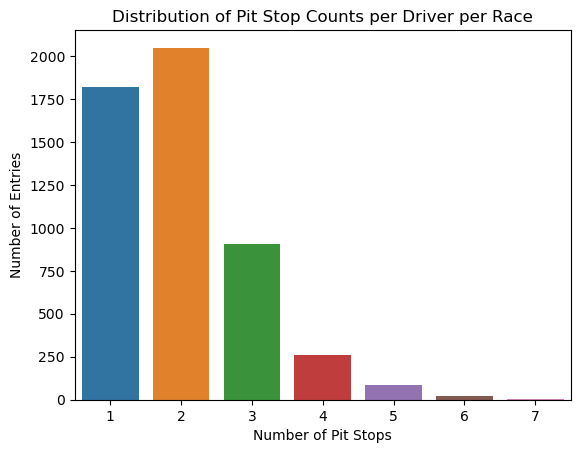

In [33]:
#Visualizing the no.of pit stops per Driver per Race

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='pit_count', data=df)
plt.title('Distribution of Pit Stop Counts per Driver per Race')
plt.xlabel('Number of Pit Stops')
plt.ylabel('Number of Entries')
plt.show()

Total Pit time

As per the above analysis, on an average the total pit time is 45 - 60 seconds, but some drivers spend enormous amount of time that is over 3 million ms (50 minutes) due to unforeseen circumstances like crash or repair therefore the average looks much larger than typical case.

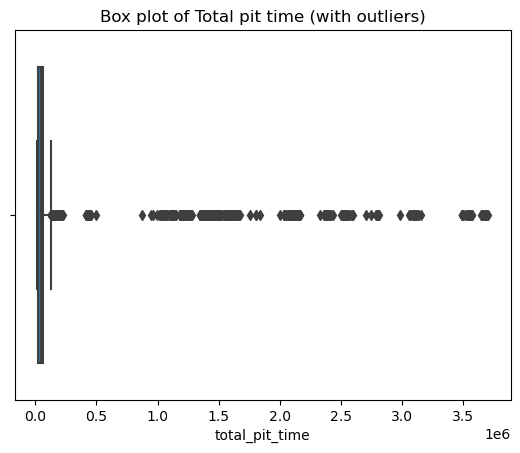

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=df['total_pit_time'])
plt.title('Box plot of Total pit time (with outliers)')
plt.show()

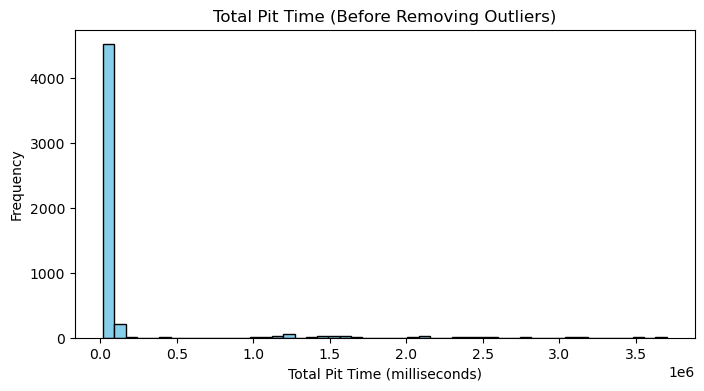

In [35]:
#Visualize original distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['total_pit_time'], bins=50, color='skyblue', edgecolor='black')
plt.title('Total Pit Time (Before Removing Outliers)')
plt.xlabel('Total Pit Time (milliseconds)')
plt.ylabel('Frequency')
plt.show()


In [36]:
#identify statistical summary
q1=df['total_pit_time'].quantile(0.25)
q3=df['total_pit_time'].quantile(0.75)
iqr=q3-q1 
upper_limit = q3+1.5*iqr

print(f"IQR = {iqr:.2f}") #Calculating Interquartile Range
print(f"Upper limit for normal range = {upper_limit:.2f} ms")

IQR = 40404.50
Upper limit for normal range = 126742.75 ms


The interquartile(IQR) range is around 40s(40404 ms) which is the median (central 50%) and which means that it is roughly between 20 and 60 seconds

The upper limit for normal range is 126s approximately which means that anything above 126s (2 mins) is considered an outlier which means that anything above 2 mins is longer to typical pit times, so they likely represent extraordinary race circumstances such as retirements or mechanical repairs.

Therefore, we are excluding from further analysis to prevent skewing of the results.

In [37]:
#Removing the outliers
df_filtered = df[df['total_pit_time'] <= upper_limit]


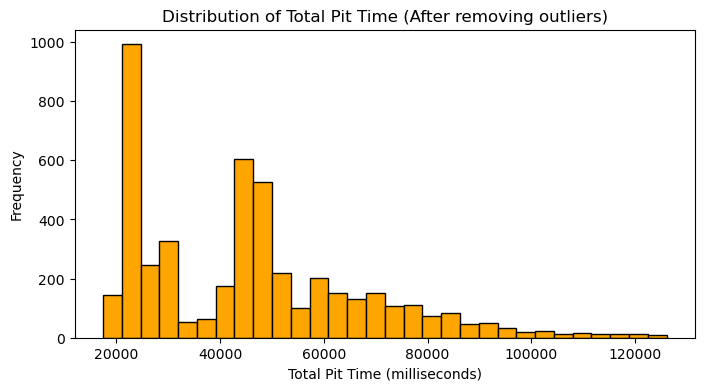

In [39]:
# Distribution of Total Pit Time
import matplotlib.pyplot as plt

#Removing entries with total_pit_time == 0 
df_nonzero = df_filtered[df_filtered['total_pit_time']>0]

plt.figure(figsize=(8,4))
plt.hist(df_nonzero['total_pit_time'], bins=30, color = 'orange', edgecolor='black')
plt.title('Distribution of Total Pit Time (After removing outliers)')
plt.xlabel('Total Pit Time (milliseconds)')
plt.ylabel('Frequency')
plt.show()

After filtering out missing and zero pit time entries, the distribution of toal pit time exhibited a positive skewed pattern. 

The majority of race entries recorded cumulative pit durations between 20s (20,000 ms) and 60s(60,000 ms) which aligns with the typizal range for one or two pit stops in modern F1 races.

Longer pit durations were less frequent, likely corresponding to drivers making additional stops or encountering minor delays.

First Stop Lap

The mean of the first stop lap is approximately 16.6 lap and Median is 15. Moreover, Q1 is 9 and Q3 is 23, which means that the majority of drivers pit for the first time in this window.  This reflects early to mid race pit windows where tire wear or fuel strategy kicks in. The outliers here which is that first pit stop happens at lap 1 and maximum happens at lap 64, this shows strategic variation where some drivers undercut early and others overcut late. 

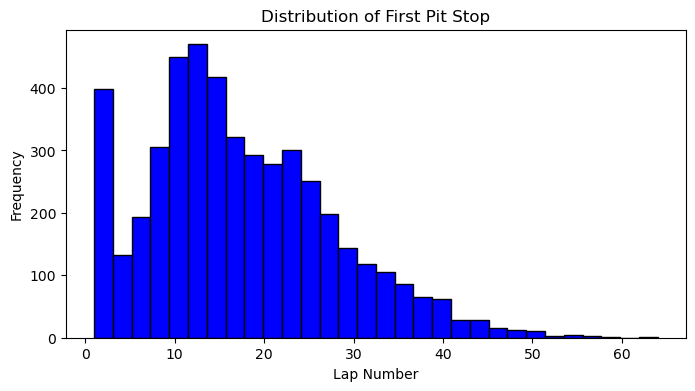

In [40]:
plt.figure(figsize=(8,4))
plt.hist(df_nonzero['first_stop_lap'], bins =30, color = 'blue', edgecolor='black')
plt.title('Distribution of First Pit Stop')
plt.xlabel('Lap Number')
plt.ylabel('Frequency')
plt.show()

Last Stop Lap

The mean of last stop lap is approximately 33.2 lap and Median is 33 which means that typical final pit stops occur mid to late race phase which means between 25 and 40. 

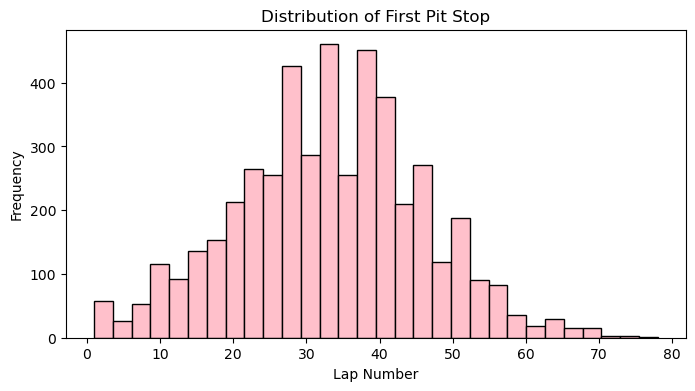

In [41]:
plt.figure(figsize=(8,4))
plt.hist(df_nonzero['last_stop_lap'], bins =30, color = 'pink', edgecolor='black')
plt.title('Distribution of First Pit Stop')
plt.xlabel('Lap Number')
plt.ylabel('Frequency')
plt.show()

The average lap for the first stop is approximately 16, while the final pit stop occured at Lap 33. 

The distribution of pit stop timing indicated that the majority of drivers executed their first stop between laps 10 and 20 and their final stop between laps 25 and 40. These results align with modern two stop race strategies. 



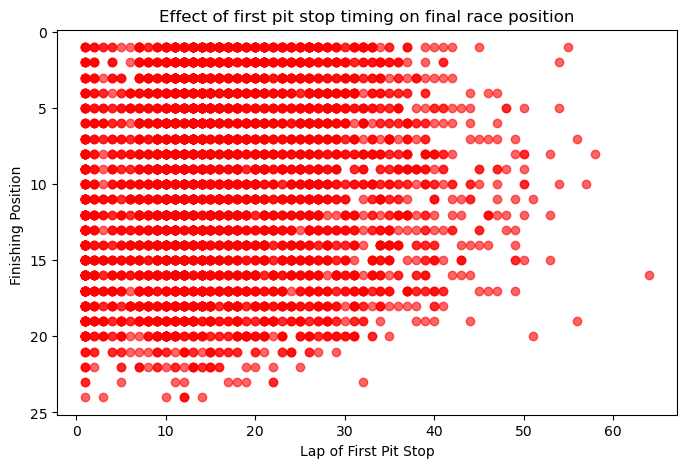

In [42]:
#Effect of first pit stop timing on final race position

plt.figure(figsize = (8,5))
plt.scatter(df_nonzero['first_stop_lap'], df_nonzero['positionOrder'], alpha=0.6, color='red')
plt.title('Effect of first pit stop timing on final race position')
plt.xlabel('Lap of First Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


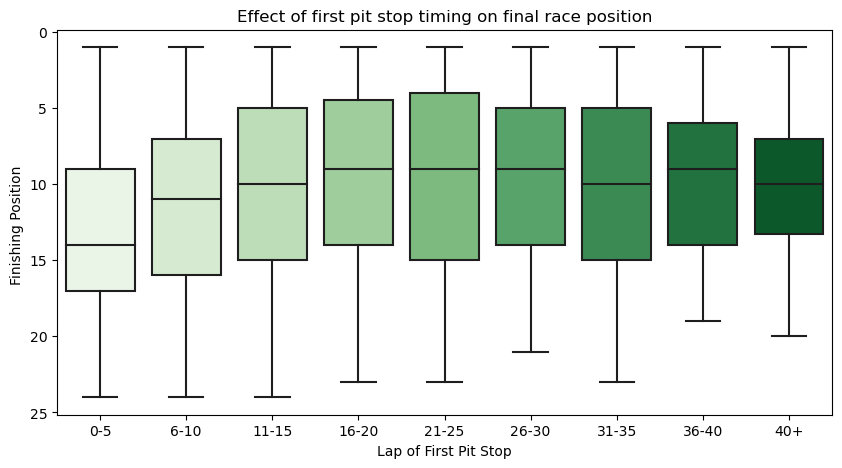

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

df_nonzero['first_stop_bin'] = pd.cut(df_nonzero['first_stop_lap'],
                                        bins=[0,5,10,15,20,25,30,35,40,65],
                                        labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+'])

plt.figure(figsize=(10,5))
sns.boxplot(x='first_stop_bin', y='positionOrder', data=df_nonzero, palette = 'Greens')
plt.title('Effect of first pit stop timing on final race position')
plt.xlabel('Lap of First Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()


The above figure presents a box plot illustrating the relationship between the first pit stop and the final race position. 

The above results show that the majority of drivers made their first pit stip between Laps 10 and 25, aligning with the standard two pit stop race strategies. 
Drivers who pitted during this window  exhibited the most consistent and competitive finishing positions with median results between 8 and 12th position. 
Early pit stops (0-5) and very late pit stops (after Lap 30) were associated with greater variability and generally poor conditions, likely reflecting unscheduled stops or excessive tire degradation.

These findings suggest that the optimal first stop timing is crucial to achieving stable race performance and minimizing risk.

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


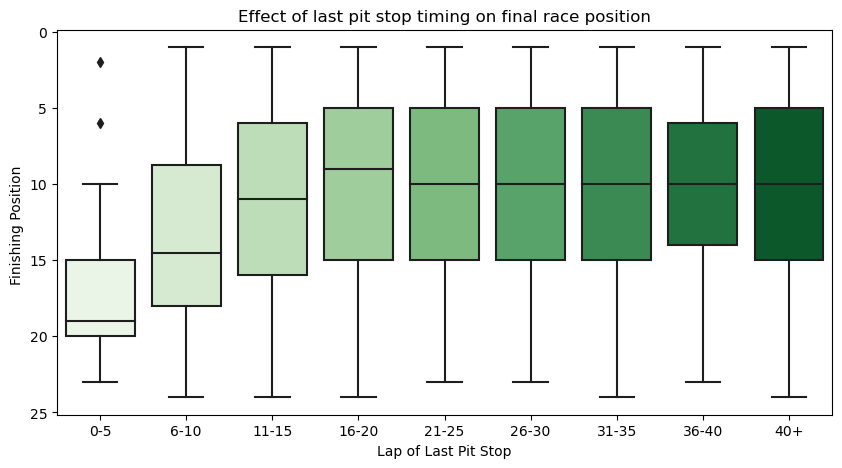

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

df_nonzero['last_stop_bin'] = pd.cut(df_nonzero['last_stop_lap'],
                                        bins=[0,5,10,15,20,25,30,35,40,65],
                                        labels=['0-5','6-10','11-15','16-20','21-25','26-30','31-35','36-40','40+'])

plt.figure(figsize=(10,5))
sns.boxplot(x='last_stop_bin', y='positionOrder', data=df_nonzero, palette = 'Greens')
plt.title('Effect of last pit stop timing on final race position')
plt.xlabel('Lap of Last Pit Stop')
plt.ylabel('Finishing Position ')
plt.gca().invert_yaxis()
plt.show()

The above figure presents a box plot illustrating the relationship between the last pit stop and the final race position. 

The above results show that the majority of drivers made their last pit stop between Laps 11 and 25 achieved a better median finishing positions, typically between 8 and 12th place. 

Early final stops (before Lap 10) correlated with significantly poorer results, likely reflecting mechanical issues or aggresive early strategies requiring multiple stops. Conversely, very late final stops (beyond lap 3) did not yield performance gains, although the variation in finishing position was smaller, suggesting a more consistent but conservative strategy. 

All in all, the results demonstrate that both excessively early and excessively late pit timinds negatively impact race performance, reinforcing the strategic importance of optimal mid-race pit windows.

In [45]:
df_nonzero[['first_stop_lap', 'last_stop_lap', 'positionOrder']].corr()


,first_stop_lap,last_stop_lap,positionOrder
first_stop_lap,1.000000,0.194195,-0.126939
last_stop_lap,0.194195,1.000000,-0.076538
positionOrder,-0.126939,-0.076538,1.000000


A pearson correlation analysis was conducted to quantify the relationship between the pit stop timing and final race position. 

The results indicate a weak negative correlation between first pit stop lap and finishing position(r = -0.13) and between last pit stop and finishing position (r = -0.08), suggesting that later pit stops are modestly associated with improved race outcomes. 

The positive correlation between first and last pit stop laps (r=0.19) further implies that drivers who delay their first stop tend to follow a correspondingly delayed strategy throughtout the race.

While these correlations are relative small, they reinforce the conclusion that pit stop timing influences but does not determine the race performance.

SUPERVISED LEARNING USING LOGISTIC REGRESSION & RANDOM FOREST

In [46]:
#Logisitic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Creating target variables
df_nonzero['top10'] = df_nonzero['positionOrder'].apply(lambda x:1 if x<=10 else 0)

#Choosing independent variables
features = [
    'pit_count',
    'avg_pit_time',
    'first_stop_lap',
    'last_stop_lap',
    'grid',          # starting position
    'laps',          # total laps completed
  #  'points',        # outcome variable proxy
    'constructorId'  # team performance
]

X=df_nonzero[features]
y=df_nonzero['top10']
             
# Convert the categorical constructorId column into dummy variables
X = pd.get_dummies(X, columns=['constructorId'], drop_first=True)

#Splitting into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#Scaling numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
print(X.head())

   pit_count  avg_pit_time  first_stop_lap  last_stop_lap  grid  laps  \
0          2       23056.0              16             36     2    58   
1          2       24193.5              16             37     6    58   
2          2       23163.0              17             36     1    58   
3          2       23108.5              14             37     5    58   
4          2       21972.5              13             34    12    58   

   constructorId_3  constructorId_4  constructorId_5  constructorId_6  ...  \
0            False            False            False            False  ...   
1            False            False            False            False  ...   
2            False            False            False            False  ...   
3            False            False            False            False  ...   
4            False            False            False             True  ...   

   constructorId_164  constructorId_206  constructorId_207  constructorId_208  \
0          

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled,y_train)

LogisticRegression(random_state=42)

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test,y_pred))

# Baseline (majority class) accuracy
baseline_acc = y_test.value_counts().max() / len(y_test)
print(f"Baseline (majority class) accuracy: {baseline_acc:.2f}")

print("\n Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("\n Classification Report:\n", confusion_matrix(y_test,y_pred))

Accuracy:  0.800709219858156
Baseline (majority class) accuracy: 0.51

 Confusion Matrix:
 [[563 151]
 [130 566]]

 Classification Report:
 [[563 151]
 [130 566]]


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
rf = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=None,     # let the trees grow fully
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8219858156028369

Confusion Matrix:
 [[578 136]
 [115 581]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       714
           1       0.81      0.83      0.82       696

    accuracy                           0.82      1410
   macro avg       0.82      0.82      0.82      1410
weighted avg       0.82      0.82      0.82      1410



Both logistic regression and random forest resulted in 56%-57% accuracy with neither algorithm demonstrating substantial improvement over the other.

The consistency suggets that pit stop metrics alone provide limited pedictive information regarding final race outcomes. 

As F1 results are influenced by a complex interplay of technical, strategic and external factors, pit stop efficiency is only one component regarding race final outcomes. 

SUPERVISED LEARNING

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# Load your previously cleaned dataset
df = pd.read_csv('f1_cleaned_data.csv')

# Quick check
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5146 entries, 0 to 5145
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         5146 non-null   int64  
 1   raceId           5146 non-null   int64  
 2   driverId         5146 non-null   int64  
 3   constructorId    5146 non-null   int64  
 4   number           5146 non-null   int64  
 5   grid             5146 non-null   int64  
 6   position         5146 non-null   object 
 7   positionText     5146 non-null   object 
 8   positionOrder    5146 non-null   int64  
 9   points           5146 non-null   float64
 10  laps             5146 non-null   int64  
 11  time             5146 non-null   object 
 12  milliseconds     5146 non-null   object 
 13  fastestLap       5146 non-null   object 
 14  rank             5146 non-null   int64  
 15  fastestLapTime   5146 non-null   object 
 16  fastestLapSpeed  5146 non-null   object 
 17  statusId      

In [52]:
#filtering data with valid pit data
df = df[(df['pit_count']>0) & (df['avg_pit_time']>0)]

#keep only recent F1 data for consistency
df = df[df['year']>=2012]

#Removing non-finishers using statusId=1  where 1 in our dataset means 'Finished'
df = df[df['statusId'] == 1 ]

#drop duplicates and missing values
df = df.dropna(subset=['pit_count','avg_pit_time','first_stop_lap','last_stop_lap','laps'])
df.reset_index(drop=True, inplace=True)

In [53]:
#Feature Engineering

#How often the driver pitted relative to race length
df['pit_frequency'] = df['pit_count']/df['laps']

#Mean stop lap
df['mean_stop_lap'] = (df['first_stop_lap'] + df['last_stop_lap'])/2

#Remaining laps after the last pit stop
df['last_stop_gap'] = df['laps'] - df['last_stop_lap']


#Selecting features for clustering
features = ['pit_count','avg_pit_time','pit_frequency','mean_stop_lap','last_stop_gap']

In [54]:
#scaling features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [55]:
#Gaussian Model for Clustering

gmm = GaussianMixture(n_components=3, random_state=42)
df['cluster'] = gmm.fit_predict(X_scaled)

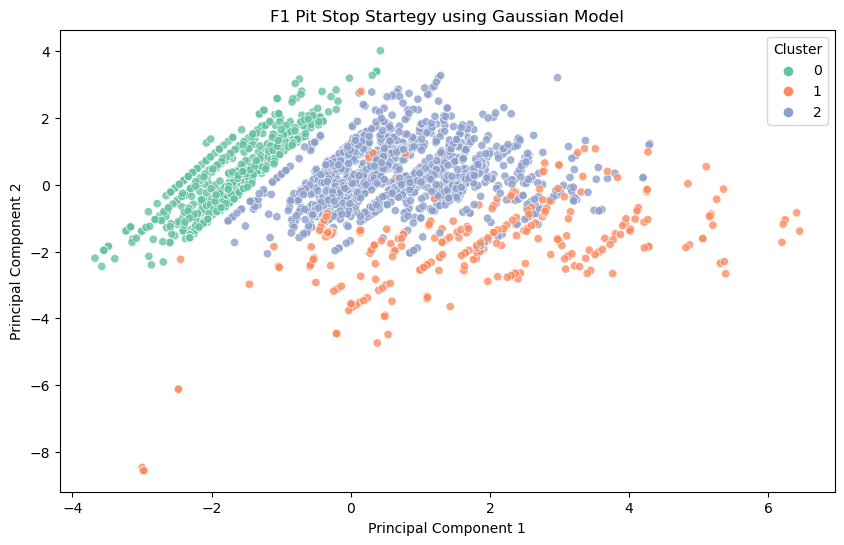

In [56]:
#Visualizing Clusters for converting the 5 factors to 2D

pca = PCA(n_components = 2)
pca_result = pca.fit_transform(X_scaled)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(x='pca1', y='pca2', hue='cluster', data=df, palette='Set2', alpha=0.8)


plt.title('F1 Pit Stop Startegy using Gaussian Model')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


The above figure represents the results of gausssian mixture model clustering projected onto two principal components using PCA. Each point represents a single driver race observation and each color indicates one of the three clusters identified by the model. 

The first principal component(x-axis) explains the majority of variance, which is majorly associated with pit frequency and total pit time, while the second component (y-axis) captures variations related to the timing and duration of pit stops. 

The clusters are clearly distinguishable which suggests that the pit stop behaviour actually exists within Formula 1 races. Cluster 0 (green) reflects conservative one-stop strategy which is characterized by lower pit frequency, cluster 1(orange) reflects multiple stop strategies while cluster 2 (blue) represents balanced two stop approaches.

The distribution of clusters confirms that pit stop variables can meaningfully diffrentiate between strategies which highlights the value of unsupervised learning for understanding patterns in Formula 1.

In [57]:
df.groupby('cluster')[['pit_count', 'avg_pit_time', 'first_stop_lap', 'last_stop_lap', 'positionOrder']].mean()


,pit_count,avg_pit_time,first_stop_lap,last_stop_lap,positionOrder
cluster,,,,,
0,1.000000,24741.408435,24.776915,24.776915,5.913430
1,3.158358,584390.202241,10.384164,34.304985,7.478006
2,2.350422,24012.001176,14.016285,38.729795,6.853438


The Gaussian Model identified three distinct pit strategy in Formula 1 races. 

Cluster 0 represented a one stop, conservative approach which usually happens mid race at 25th lap approximately and has the best average finishing position. 

Cluster 1 reprsented a 3 stop strategy with long pit time and with first pit stop happening at 10th lap and the last one at 34th lap while they also the weakest position. 

Cluster 2 represents a balanced strategy with a two stop pit strategy with moderate timing and average performance.

DISCUSSION AND IMPLICATION

The findings of this study confirms that pit frequency and timing exert a measurable yet limited influence on final race outcomes in Formula 1. 

Statistical analysis revealed that most races feature one to two pit stops, which typicall occurs between 10th and 25th lap. While the correlation between pit timing and final position was negative (r = -0.13 for first stop) which indicates that later stops are associated with better finishes, the relationship wasn't strong enough to suggest direct causation. This concludes that while pit startegy contributre to rare success, it operates with a broader system such as tire degradation, safety cars, and vehicle reliability. 

The unsupervised learning analysis was examined using Gaussian Mixture Model (GMM) which provided a deeper understanding of race strategies. Three distinct clusters were identified:

1. Cluster 0 represented a one stop, conservative approach which usually happens mid race at 25th lap approximately and has the best average finishing position.

2. Cluster 1 reprsented a 3 stop strategy with long pit time and with first pit stop happening at 10th lap and the last one at 34th lap while they also the weakest position.

3. Cluster 2 represents a balanced strategy with a two stop pit strategy with moderate timing and average performance.

The cluster seperation observed through PCA confirms that pit related variables distinguishes different strategic behaviors. However, the overlap between clusters also suggests that team decisions are adaptiverather than fixed, reflecting dynamic responses to evolving race conditions.

Supervised learning experiments using logistic regression and random forest classifiers further validated these insights. Once features directly encoding performances outcomes were removed, predictive accuracy stabilized at approximately 56%, underscoring that pit stop metrics alone cannot accurately forecast finishing positions.This highlights the complexity of Formula 1 where race performance is influences by an interaction of mechanical environmental and tactical elements. 

All in all, these findings imply that pit-stop efficiency and stability-rather than frequency are the key determinants of competitive advantage. Teams benefit most form minimizing unnecessary stops and ensuring operationsal precision during pit executions. 

For researchers, the study demonstrates that combining statistical analysis with unsupervised clustering yields richer interpretive insights than purely predcitive models.

Research Question 2:
    
    To what extent do Sprint race results influence final race outcomes in Formula 1?

Objective:
    
    To determine whether a driver's finishing position in the Sprint race has a measurable impact on the final Grand Prix position, and if this influence varies across seasons since sprint races were introduced.
    

POV: Sprint races began in 2021, so our analysis will include data from 2021 to 2024

In [58]:
# Step 1 - Replacing '\N' strings with NaN
races = races.replace("\\N", np.nan)
results = results.replace("\\N", np.nan)
sprint_results = sprint_results.replace("\\N", np.nan)

#Step 2 - Filtering the races that actually had sprint events that is after 2021
sprint_races = races[races['sprint_date'].notna()]

##Step 3 - filtering both datasets to include only sprint raceIds
sprint_results = sprint_results[sprint_results['raceId'].isin(sprint_races['raceId'])]
results = results[results['raceId'].isin(sprint_races['raceId'])]

#verifying the results
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
25140,25146,1061,1,131,44,2,1,1,1,25.0,52,1:58:23.284,7103284,45,2,1:29.699,236.430,1
25141,25147,1061,844,6,16,4,2,2,2,18.0,52,+3.871,7107155,45,5,1:30.569,234.159,1
25142,25148,1061,822,131,77,3,3,3,3,15.0,52,+11.125,7114409,45,4,1:30.524,234.275,1
25143,25149,1061,846,1,4,5,4,4,4,12.0,52,+28.573,7131857,44,9,1:31.420,231.979,1
25144,25150,1061,817,1,3,6,5,5,5,10.0,52,+42.624,7145908,51,8,1:31.284,232.325,1


In [59]:
#Step 4 - Removing rows where positionOrder is missing

sprint_results = sprint_results.dropna(subset=['positionOrder'])
results = results.dropna(subset=['positionOrder'])

#Converting to numeric safely

sprint_results['positionOrder'] = pd.to_numeric(sprint_results['positionOrder'], errors='coerce')
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')

#Droping rows that turned into Nan after conversion
sprint_results = sprint_results.dropna(subset=['positionOrder'])
results = results.dropna(subset=['positionOrder'])


#Step 5 - Removing DNFs
if 'status' in results.columns:
    results = results[~results['status'].str.contains('DNF|Disqualified|Retired', case=False, na=False)]
    

In [60]:
from scipy.stats import pearsonr

#Merge main and sprint results
#merged = (sprint_results
 #        .merge(results, on=['raceId','driverId'], suffixes=('_sprint','_race'))
  #       .merge(drivers[['driverId','forename','surname']], on='driverId', how='left')
   #      .merge(sprint_races[['raceId','year','name']], on='raceId', how='left'))

#Step 6 - Merging Sprint and race results
merged = sprint_results.merge(
    results,
    on=['raceId', 'driverId'],
    suffixes=('_sprint', '_race')
)

#Step 7 - Adding year from races table
merged = merged.merge(races[['raceId','year']], on='raceId', how='left')

#Step 8 - Computing position change
merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

#merged = merged['raceId','driverId','positionOrder_sprint','positionOrder_race']

#merged = merged.dropna(subset=['positionOrder_sprint','positionOrder_race'])
#merged = merged[(merged['positionOrder_sprint'] > 0) & (merged['positionOrder_race'] > 0)]

#merged = merged.merge(races[['raceId','year']], on='raceId', how='left')

merged.head(3)

,resultId_sprint,raceId,driverId,constructorId_sprint,number_sprint,grid_sprint,position_sprint,positionText_sprint,positionOrder_sprint,points_sprint,...,laps_race,time_race,milliseconds_race,fastestLap_race,rank,fastestLapTime_race,fastestLapSpeed,statusId_race,year,position_change
0,1,1061,830,9,33,2,1,1,1,3,...,0,NaN,NaN,NaN,0,NaN,NaN,4,2021,-19
1,2,1061,1,131,44,1,2,2,2,2,...,52,1:58:23.284,7103284,45,2,1:29.699,236.430,1,2021,1
2,3,1061,822,131,77,3,3,3,3,1,...,52,+11.125,7114409,45,4,1:30.524,234.275,1,2021,0


In [61]:
#Correlation Analysis
# Testing how closely sprint results relate to final race results

from scipy.stats import pearsonr
corr, p_value = pearsonr(merged['positionOrder_sprint'], merged['positionOrder_race'])
print(f"Correlation between Sprint and Main Race positions: {corr:.2f} (p={p_value:.7f})")


Correlation between Sprint and Main Race positions: 0.51 (p=0.0000000)


The p-value being effectively zero means the relationship between Sprint and Main Race Results is statistically significant beyond any reasonable doubt. In practical terms, it confirms that the observed correlation (0.51) is real.

The correlation between Sprint and main race finishing positions was statistically significant (r=0.51, p<0.0001) indicating that the relationship is highly unlikely to have occured by chance. The extremely small p-value (approximately zero) reflects both the large dataset size and the consistency of the observed trend, rather than implying a perfect or casual relationship.

A pearson correlation coefficient of 0.51(p<0.001) was observed between sprint finishing position and final race position across all sprint weekends(2021-2024). This result indicates a moderate, statistically significant positive relationship, suggesting that the drivers who perform strongly in sprint races are more likely to achieve competitive results in the main Grand Prix. 

However, the moderate strength of the correlation implies that other race day factors such as pit stop strategy, weather conditions and mechnical reliability continue to play substantial roles in determining final outcomes.

In [62]:
#Regression Analysis
#Quantifying to what extent 'Sprint Position' predicts race finish

import statsmodels.api as sm

X = sm.add_constant(merged['positionOrder_sprint'])
y = merged['positionOrder_race']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:     positionOrder_race   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     127.5
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           1.66e-25
Time:                        14:15:16   Log-Likelihood:                -1086.7
No. Observations:                 360   AIC:                             2177.
Df Residuals:                     358   BIC:                             2185.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.1184 

A simple linear regression was conducted to quantify the extent to which sprint results predict Grand Prix finishing positions. The model produced as R2 of 0.263 which indicates that the sprint performance explains approximately 26% of the variation in the main race outcomes (so this means that it has moderate explanatory power and that other outcomes like race-day strategy, pit stop, weather matter as well).

The regresssion coefficient for Sprint position(β = 0.5125, p<0.001) confirms a statistically significant positive relationship, whereby each one-place drop in sprint finishing position corresponds to an average 0.5 place decline in the main race(so this means that for every one place drop in sprint position, the driver's race position drops by about half a place, so sprint position is partial but meaningful predictor of final performance)

These findings reinforce the correlation analysis (r=0.51) and suggest that while sprint results meaningfully influence final putcomes, the majority of race performance is determined by aditional factprs such as pit stop frequency, tire degradation and race incidents. In essence, sprint success provides a competitive advantage but remains one of the several contributors to overall race performance.

In [63]:
#Feature Engineering

#1 - Position gain & loss
merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

#2 - Ratio for relative improvement
merged['position_ratio'] = merged['positionOrder_race']/merged['positionOrder_sprint']

#3 - Binary indicators for classification
merged['top10_sprint'] = (merged['positionOrder_sprint'] <= 10).astype(int)
merged['top10_race'] = (merged['positionOrder_race'] <= 10).astype(int)

#Sanity check
merged[['positionOrder_sprint','positionOrder_race','position_change','position_ratio','top10_sprint','top10_race']].head()

,positionOrder_sprint,positionOrder_race,position_change,position_ratio,top10_sprint,top10_race
0,1,20,-19,20.0,1,0
1,2,1,1,0.5,1,1
2,3,3,0,1.0,1,1
3,4,2,2,0.5,1,1
4,5,4,1,0.8,1,1


In [64]:
#Mean position change by sprint performance

merged.groupby('top10_sprint')['position_change'].mean()
merged['position_change'].describe()

count    360.000000
mean       0.000000
std        5.701488
min      -19.000000
25%       -2.000000
50%        0.500000
75%        3.000000
max       19.000000
Name: position_change, dtype: float64

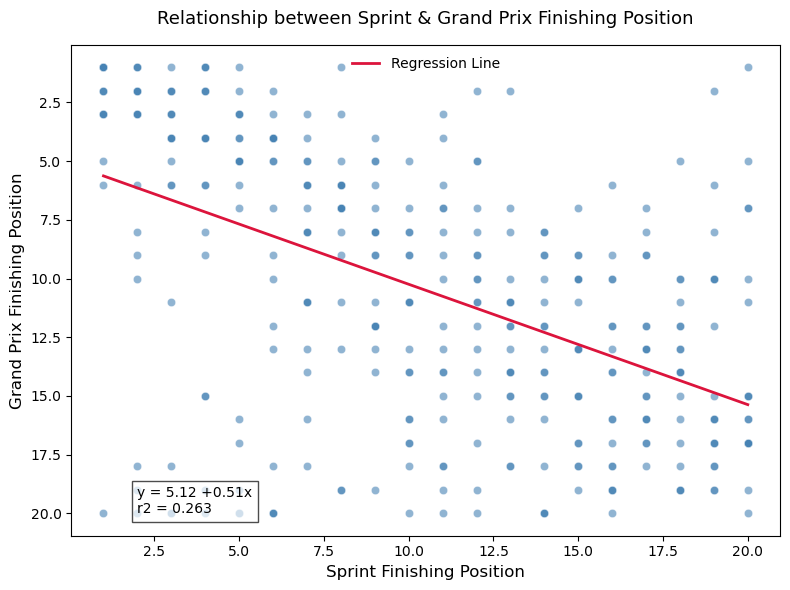

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

r2=0.263
coef=0.5125
intercept=5.1184

x_vals = np.linspace(1, merged['positionOrder_sprint'].max(),50)
y_vals = intercept + coef * x_vals

plt.figure(figsize=(8,6))
sns.scatterplot(x='positionOrder_sprint',y='positionOrder_race',
               data=merged, alpha=0.6,color='steelblue',edgecolor='white')

plt.plot(x_vals,y_vals,color='crimson',linewidth=2, label='Regression Line')

plt.title('Relationship between Sprint & Grand Prix Finishing Position', fontsize=13, pad=15)
plt.xlabel('Sprint Finishing Position', fontsize=12)
plt.ylabel('Grand Prix Finishing Position', fontsize=12)

eq_text = f'y = {intercept:.2f} +{coef:.2f}x\nr2 = {r2:.3f}'
plt.text(2,20,eq_text,fontsize=10,color='black',bbox=dict(facecolor='white',alpha=0.7))

plt.legend(frameon=False)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Figure X visualizes the linear relationship between sprint finishing position and main race finishing position across sprint weekends from 2021-2024. Each point represents a drivers performance across both sessions, and the fitted regression line illustrates the positive association (R2=0.263). The downward slope towards the top-left of the graph shows that drivers with stronger sprint results tend to achieve higher final positions in the main race. However, the moderate dispersion around the line indicates that other race day variables continue to influence the outcome.

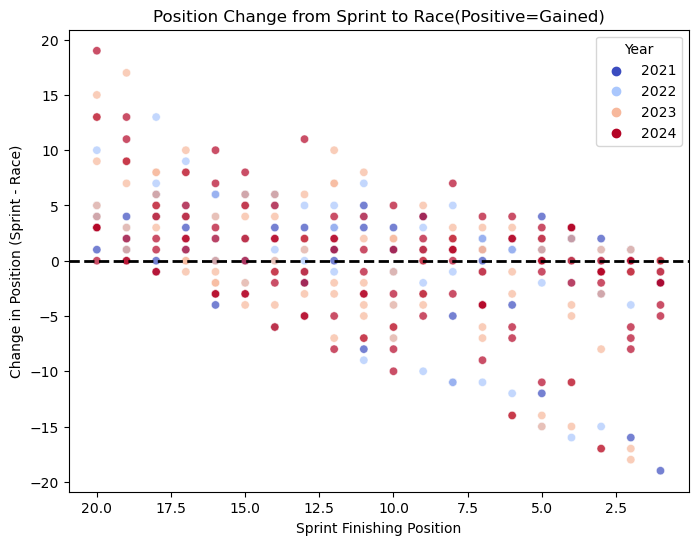

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

merged['position_change'] = merged['positionOrder_sprint'] - merged['positionOrder_race']

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='positionOrder_sprint',
    y='position_change',
    hue='year',
    data=merged,
    palette='coolwarm',
    alpha=0.7
)

plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Position Change from Sprint to Race(Positive=Gained)')
plt.xlabel('Sprint Finishing Position')
plt.ylabel('Change in Position (Sprint - Race)')
plt.legend(title='Year')
plt.gca().invert_xaxis()
plt.show()

The above figure shows the positional change from Sprint to main race across all sprint weekends (2021-2024).

Drivers that finish in the top five during the Sprint tend to maintain similar positions in the Grand Prix, whereas mid filed and lower grid drivers exhibit greater volatility. The presence of many positive changes among back markers indicate that Sprint results are not deterministic; opportunties for recovery remain high in the full race. 

Over successive seasons, the variance in position changes appears to narrow, suggesting that the predictive influence of Sprint results on main race outcomes has strengthened as the Sprint format matured.

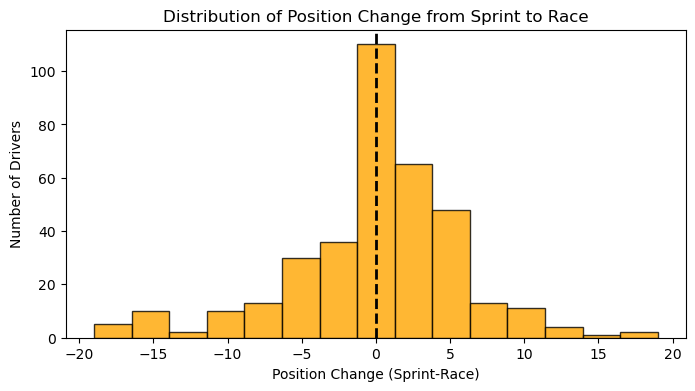

In [67]:
plt.figure(figsize=(8,4))
plt.hist(merged['position_change'].dropna(),bins=15,color='orange',edgecolor='black',alpha=0.8)
plt.title('Distribution of Position Change from Sprint to Race')
plt.xlabel('Position Change (Sprint-Race)')
plt.ylabel('Number of Drivers')
plt.axvline(0,color='black',linestyle='--',linewidth=2)
plt.show()

The above figure represents the distribution of position changes between Sprint and Grand Prix results across all Sprint Weekends(2021-2024).

The distribution is centered around zero, with most drivers finishing within one or two places of their Sprint result.This indicates that Sprint performance is moderately predictive of the final race outcome. 

A slightly positive skew suggets that more drivers tend to gain rather than lose positions in the main race, likely reflecting opportunities for overtaking and strategic improvements over the longer race duration.

Outliers on both ends correspond to drivers affected by retirements, mechanical issues, or exceptional race recoveries. 

/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


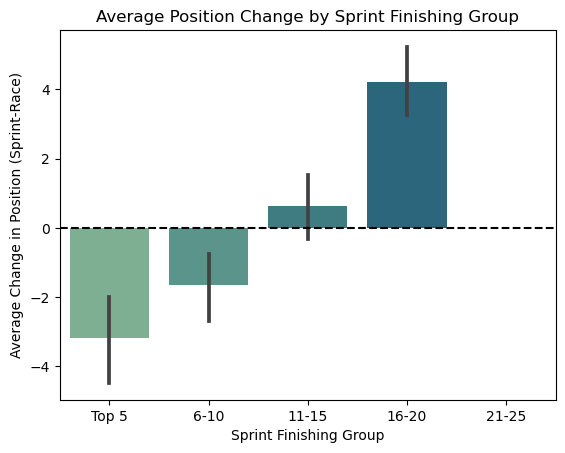

In [68]:
merged['sprint_group'] = pd.cut(
    merged['positionOrder_sprint'],
    bins=[0,5,10,15,20,25],
    labels=['Top 5','6-10','11-15','16-20','21-25'])

sns.barplot(x='sprint_group',y='position_change',data=merged,palette='crest')
plt.title('Average Position Change by Sprint Finishing Group')
plt.xlabel('Sprint Finishing Group')
plt.ylabel('Average Change in Position (Sprint-Race)')
plt.axhline(0,color='black',linestyle='--')
plt.show()

The above figure illustrates the average change in finishing position between Sprint and Grand Prix session, grouped by Sprint finishing bracket. 

Front runners (Top 5) tend to lose positions in the main race, whereas lower grid drivers(positions 16-20) typically gain several.

This pattern suggests that Sprint performance provides a stable indicator of race potential for the midfield, but less for extreme positions. 

The observed trend aligns with the idea that longer race durations amplify strategic effects, allowing lower-starting drivers to recover while increasing variability among top contenders. 

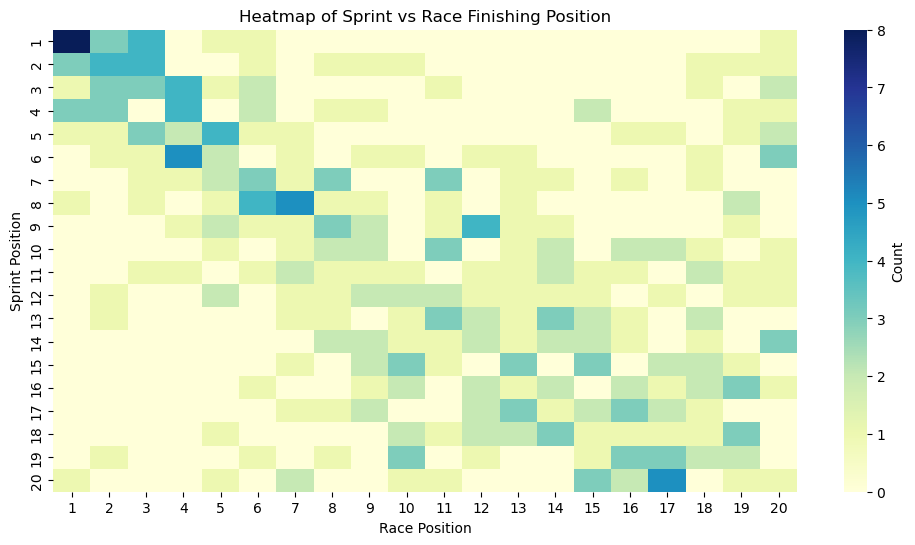

In [69]:
pivot = pd.crosstab(merged['positionOrder_sprint'], merged['positionOrder_race'])

plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap='YlGnBu',cbar_kws={'label':'Count'})
plt.title('Heatmap of Sprint vs Race Finishing Position')
plt.xlabel('Race Position')
plt.ylabel('Sprint Position')
plt.show()

Figure above illustrates a heatmap comparing Sprint and Grand Prix finishing positions across all Sprint weekends(2021-2024)

The strong diagnol pattern indicates that Sprint performance is a moderately reliable indicator of race results - particularly for the top and bottom segments of the grid. 

The slight rightward shift among top Sprint finishers suggets. that front-runners often lose positions in the full race, while the upward shading toward the lower sprint rows highlights consistent gains for backbenchers.

The visualization reinforces the earlier regression and correlation finsings, confirming that Sprint race resutls influence - but do not completely determine the final race outcomes. 

# Applying Models

In [70]:
#Step 1 - Preparing Data for Modelling

model_df = merged[[
    'positionOrder_sprint',
    'grid_sprint',
    'points_sprint',
    'constructorId_sprint',
    'positionOrder_race',
    'top10_sprint',
    'top10_race'
]].dropna()

model_df.head()

,positionOrder_sprint,grid_sprint,points_sprint,constructorId_sprint,positionOrder_race,top10_sprint,top10_race
0,1,2,3,9,20,1,0
1,2,1,2,131,1,1,1
2,3,3,1,131,3,1,1
3,4,4,0,6,2,1,1
4,5,6,0,1,4,1,1


In [71]:
#Features and target
X = model_df[['positionOrder_sprint','grid_sprint','points_sprint','constructorId_sprint']]
y = model_df['top10_race']

#Splitting dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#Scaled & Standardized
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [72]:
#Applying Logistic Regression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled,y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("Accuracy of Logistic Regression is:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred_lr))
print("Classification Report: ", classification_report(y_test,y_pred_lr))

Accuracy of Logistic Regression is: 0.7222222222222222
Confusion Matrix: 
 [[46 16]
 [14 32]]
Classification Report:                precision    recall  f1-score   support

           0       0.77      0.74      0.75        62
           1       0.67      0.70      0.68        46

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108



# Don't use the following version of Random Forest

In [73]:
#Applying Random Forest

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy of Random Forest is:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix: \n", confusion_matrix(y_test,y_pred_lr))
print("Classification Report: ", classification_report(y_test,y_pred_lr))

Accuracy of Random Forest is: 0.7222222222222222
Confusion Matrix: 
 [[46 16]
 [14 32]]
Classification Report:                precision    recall  f1-score   support

           0       0.77      0.74      0.75        62
           1       0.67      0.70      0.68        46

    accuracy                           0.72       108
   macro avg       0.72      0.72      0.72       108
weighted avg       0.72      0.72      0.72       108



In [74]:
#Building a decision tree for my reference
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

# Pick one tree from the trained forest
single_tree = rf.estimators_[0]

# Print the textual decision rules
tree_rules = export_text(single_tree, feature_names=list(X.columns))
print(tree_rules)


|--- grid_sprint <= 16.50
|   |--- positionOrder_sprint <= 8.50
|   |   |--- positionOrder_sprint <= 5.50
|   |   |   |--- constructorId_sprint <= 172.50
|   |   |   |   |--- grid_sprint <= 4.50
|   |   |   |   |   |--- points_sprint <= 4.50
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- points_sprint >  4.50
|   |   |   |   |   |   |--- constructorId_sprint <= 70.00
|   |   |   |   |   |   |   |--- points_sprint <= 5.50
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- points_sprint >  5.50
|   |   |   |   |   |   |   |   |--- positionOrder_sprint <= 2.50
|   |   |   |   |   |   |   |   |   |--- constructorId_sprint <= 3.50
|   |   |   |   |   |   |   |   |   |   |--- grid_sprint <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |   |--- grid_sprint >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- constructo

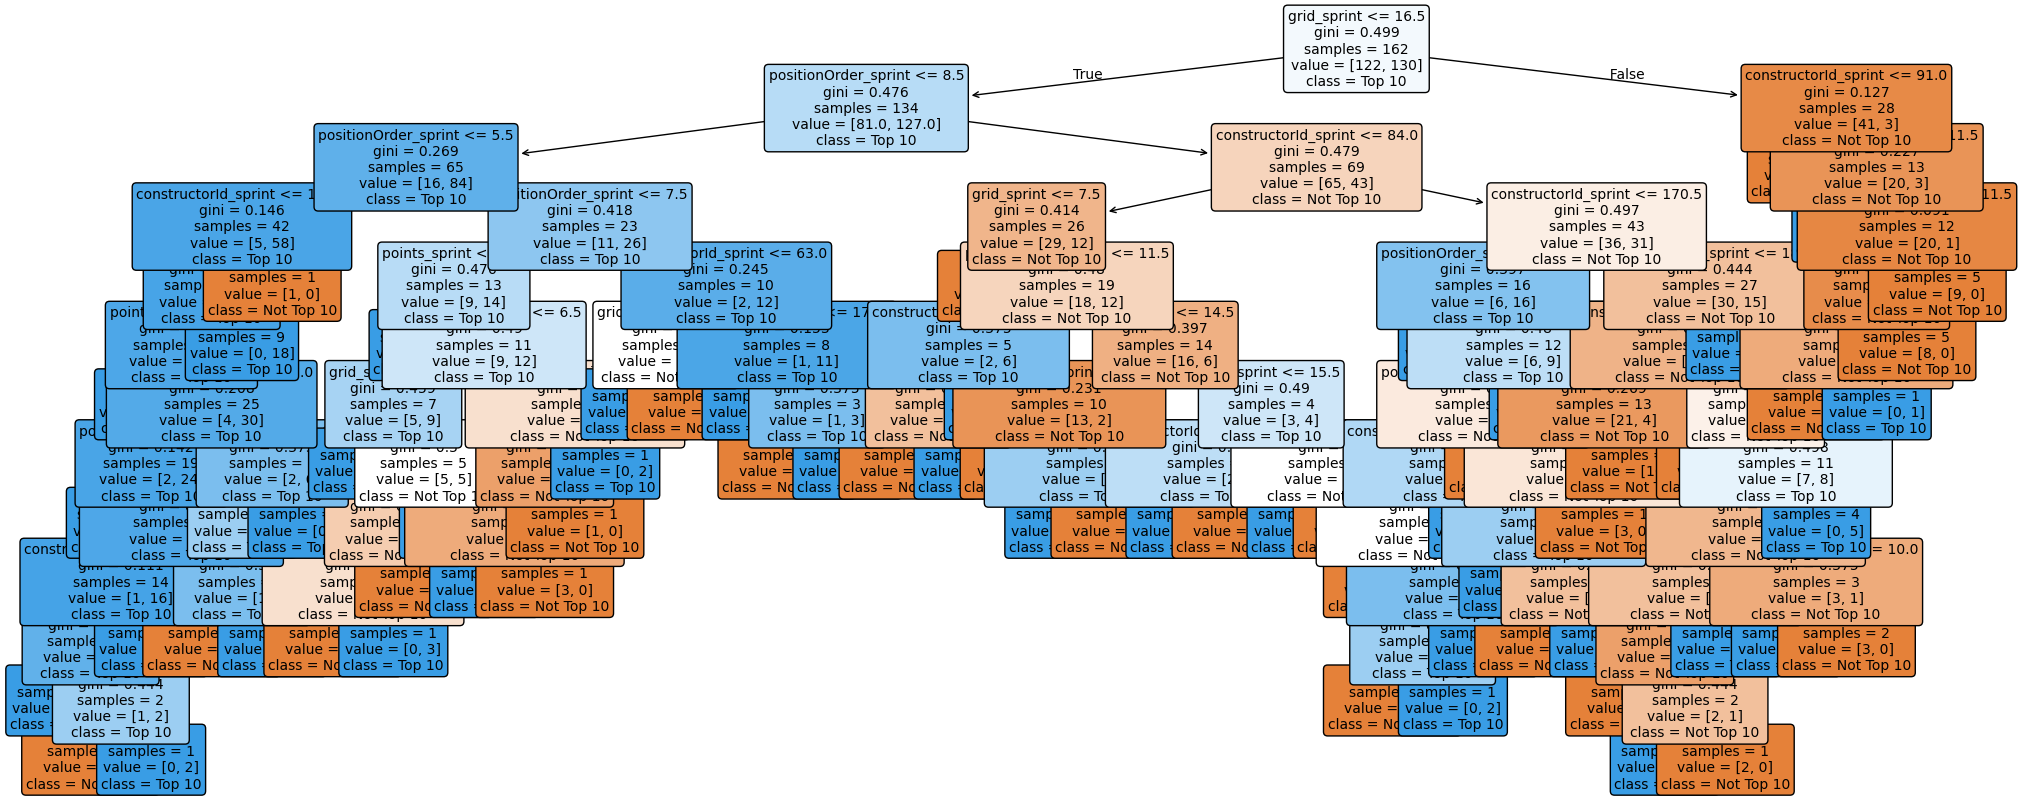

In [77]:
#for my reference
plt.figure(figsize=(25,10))
plot_tree(
    single_tree,
    feature_names=list(X.columns),
    class_names=['Not Top 10','Top 10'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


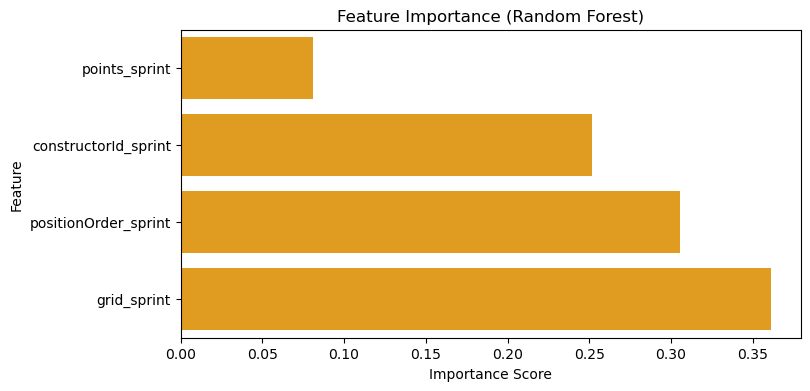

In [78]:
#Feature importance

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=True)

plt.figure(figsize=(8,4))
sns.barplot(x=feat_importances, y=feat_importances.index,color='orange')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

The random forest feature importance analysis indicates that grid position and sprint finishing order are the strongest predictors of main race outcomes, together accounting for more than 60% of model importance.

This suggests that track position and underlying car performance (constructor) remain decisive factors even across two sperate race formats.

Sprint points add minimal predictive value because they largely duplicate positional data. 

Overall, the Random Forest highlights that drivers starting or finishing near the front in the sprint are more likely to achieve a top 10 finishing position in the Grand Prix.

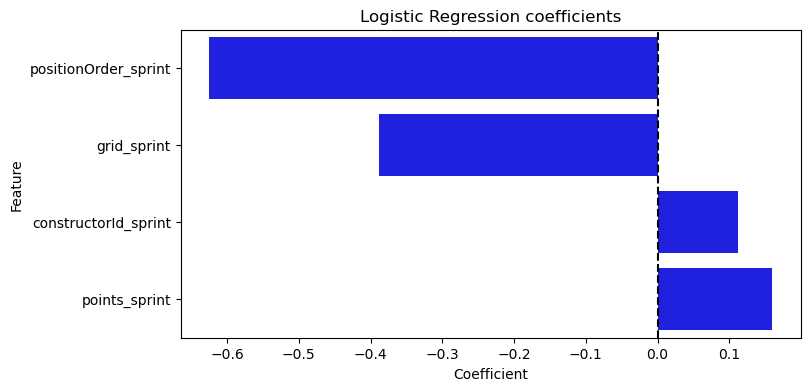

In [79]:
#Logistic Regression coefficients

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient',ascending=True)

plt.figure(figsize=(8,4))
sns.barplot(x='Coefficient', y='Feature',data= coef_df,color='blue')
plt.axvline(0,color='black',linestyle='--')
plt.title('Logistic Regression coefficients')
plt.show()

The figure illustrates the direction and strength of each predictor's influence on the probablity of finishing within the top ten positions in the Grand Prix.Negative coefficients indicate that higher feature values decrease the likelihood of a top ten result while positive coefficients increases it. 

The sprint finishing position(positionOrder_sprint) and sprint grid position(grid_sprint) exhibit the largest negative coefficients, confirming that drivers who start or finish further down the order in the sprint are substantially less likely to achieve a top 10 finish in the race. Contrary, constructorId_sprint and points_sprint display small positive coefficients, implying that team competiteveness and prior sprint points contribute marginally to improved race performance.

All in all, the results emphasize that track position achieved during the sprint remains the most decisive factor in predicting subsequent race outcomes, aligning with the correlation and regression findings that earlier race performance stronly translates into main race sucess.

In [80]:
y_test.value_counts()


top10_race
0    62
1    46
Name: count, dtype: int64

In [81]:
# Baseline (majority class prediction)
baseline_acc = y_test.value_counts().max() / len(y_test)
print(f"Baseline (majority class) accuracy: {baseline_acc:.2f}")


Baseline (majority class) accuracy: 0.57


To contextualize model performance, a majority class baseline was computer using the distribution of the test set(46 top-10 cases and 62 non-top-10 cases).

The baseline yielded an accuracy of 57% meaning that a naive classifier predicting all drivers as non-top 10 would achieve roughly 57% correctness. 

In contrast, both the logistic Regression and Random Forest classifiers achieved approximately 72% accuracy, representing a 15% point improvement over baseline. 

This confirms that the model captures meaningful predictive patterns rather than simply reflecting class imbalance.

# Use the below version of Random Forest

In [82]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight=class_weights)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight={0: 1.0677966101694916,
                                     1: 0.9402985074626866},
                       n_estimators=200, random_state=42)

In [83]:
y_pred_rf = rf.predict(X_test)
confusion_matrix(y_test, y_pred_rf)


array([[40, 22],
       [13, 33]])

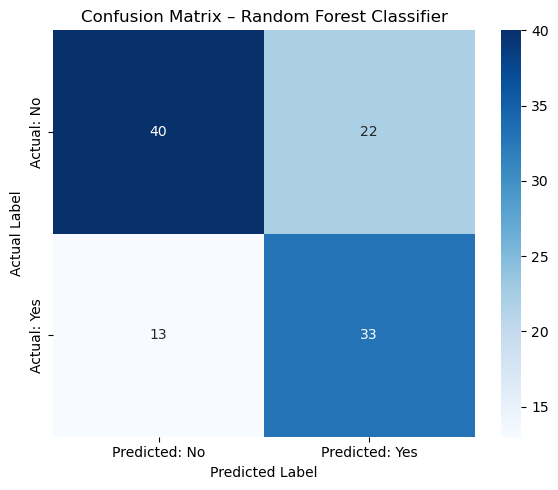

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have y_test and y_pred_rf
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes']
)

plt.title('Confusion Matrix – Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


The heatmap illustrates the random forest model's classification peerformance in the predicting top ten Grand prix finishes based on sprint metrics. 

Darker diagnol(40 true negatives and 33 true positives) indicate correct classifications performance in predicting top-ten Grand Prix finishes based on sprint metrics.

Overall the model demonstrates balanced predictive capability, correctly identifying approximately 68% of all the outcomes, confirming that sprint performance is a moderately reliable indicator of race-day success.

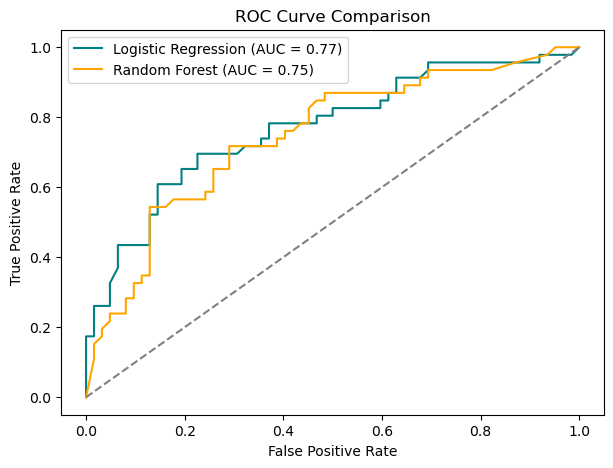

In [85]:
from sklearn.metrics import roc_curve, auc

# Get probabilities instead of labels
y_pred_lr_prob = log_reg.predict_proba(X_test_scaled)[:,1]
y_pred_rf_prob = rf.predict_proba(X_test)[:,1]

# Compute ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot
plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})', color='teal')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', color='orange')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


# ROC Curve Comparison between logistic regression and Random Forest

The figure above compares the ROC curves for Logistic Regression and Random Forest classifiers trained to predict top-ten Grand Prix Finishes using sprint race features.

Both models show strong discriminatory ability, with AUC scores of 0.77 (Logistic Regression) and 0.75 (Random Forest), well above the random baseline of 0.5. This indicates that sprint performance metrics provide meaningful predictive information for main-race outcomes.

The higher AUC for logistic regression suggets that the relationship between sprint and final race performance is linear, and additional non-linear modelling through Random Forest does not significantly enhance prediction accuracy. 


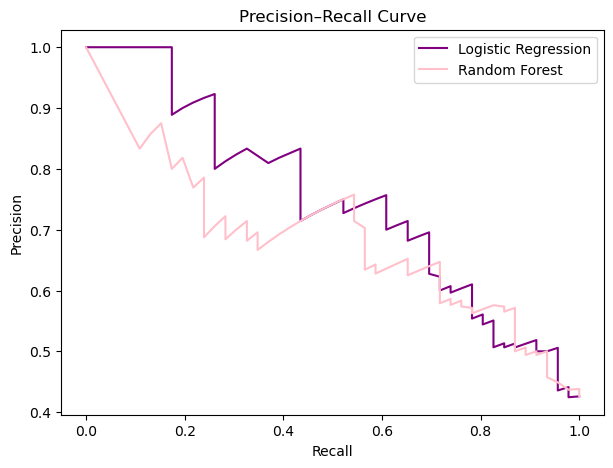

In [86]:
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_lr_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_rf_prob)

plt.figure(figsize=(7,5))
plt.plot(rec_lr, prec_lr, label='Logistic Regression', color='purple')
plt.plot(rec_rf, prec_rf, label='Random Forest', color='pink')
plt.title('Precision–Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

The figure compares the precision-recall trade off for the logistic regression and random forest classifiers predicting top-ten Grand Prix finishes using sprint metrics. 

Both model maintain high precision across most recall levels, indicating strong positive class discrimination even under varying decision thresolds. 

Logistic regression exhibits slightly superior balance, with consitently higher precision for the same recall values, suggesting that the relationship between sprint and race results is largely linear and stable.

The Random Forest model captures a similar trend but with marginally lower precision, reflecting a greater tendency to overpredict top-ten outcomes. 


# Applying Unsupervised Learning (kMeans)

In [87]:
features = merged[['positionOrder_sprint','positionOrder_race','position_change','points_sprint']]

In [88]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [89]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
merged['cluster'] = kmeans.fit_predict(X_scaled)

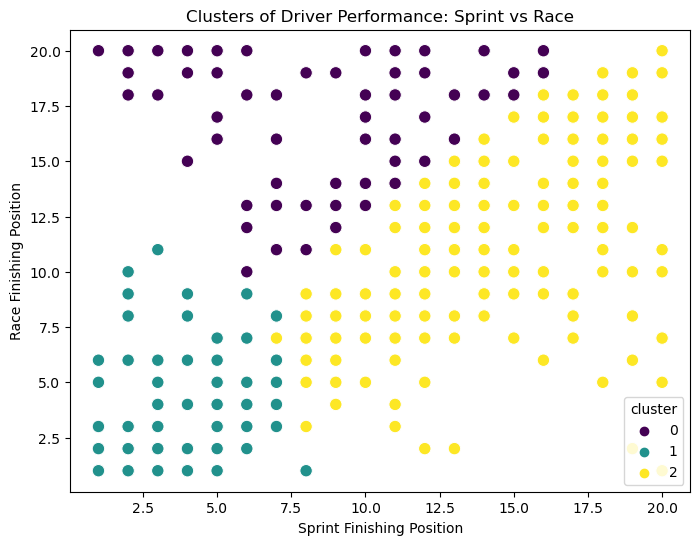

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='positionOrder_sprint',
    y='positionOrder_race',
    hue='cluster',
    data=merged,
    palette = 'viridis',
    s=80
)

plt.title('Clusters of Driver Performance: Sprint vs Race')
plt.xlabel('Sprint Finishing Position')
plt.ylabel('Race Finishing Position')
plt.show()

The figure illustrates three clusters of driver performance patterns derived using the K-Means clustering algorithm.

Cluster 1 in green represents consistent performers who maintain strong finishing positions across both sprint and main race sessions.

Cluster 0 in purple captures the drivers whose position has declined, drivers who perform well in the sprint but lose positions in the Grand Prix.

Cluster 2 denotes strugglers who basically finish low in both sessions. 

This unsupervised learning analysis highlights that while sprint results moderately predict race performance, drivers exhibit heterogeneous behaviors in translating sprint success into main race outcomes. 

Such clustering provides a nuanced understanding of performance patterns that complements the supervised predictive findings.


In [91]:
kmeans = KMeans(n_clusters=3, random_state=42)
merged['cluster'] = kmeans.fit_predict(X_scaled)


In [92]:
# Compute mean sprint and race stats per cluster
cluster_summary = merged.groupby('cluster')[['positionOrder_sprint', 'positionOrder_race', 'position_change', 'points_sprint']].mean().round(2)
print(cluster_summary)


         positionOrder_sprint  positionOrder_race  position_change  \
cluster                                                              
0                        8.86               16.72            -7.87   
1                        3.60                3.82            -0.22   
2                       14.46               11.24             3.22   

         points_sprint  
cluster                 
0                 1.41  
1                 4.77  
2                 0.06  


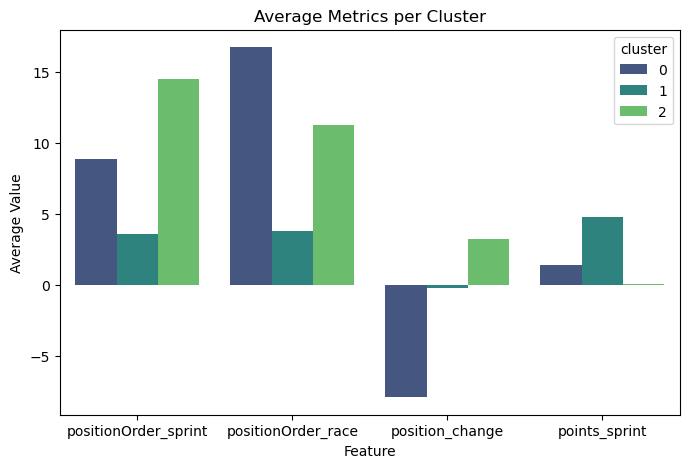

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=cluster_summary.reset_index().melt(id_vars='cluster'),
            x='variable', y='value', hue='cluster', palette='viridis')
plt.title('Average Metrics per Cluster')
plt.xlabel('Feature')
plt.ylabel('Average Value')
plt.show()


# Average Sprint and Race Metrics by Driver Cluster

The figure presents the mean sprint and race performance metrics for each driver cluster identified through the K-Means algorithm.

Cluster 1 (teal) represents consistent performers, maintaining strong finishing positions and scoring the highest average sprint points.

Cluster 0 (dark blue) captures decliners, who perform well in the sprint but lose significant ground during the Grand Prix, indicated by a large negative position change.

Cluster 2 (light green) includes strugglers, consistently finishing in the lower order of both sessions.

This quantitative summary reinforces the earlier visual clustering results, confirming that while sprint results moderately predict main-race outcomes, driver behavior patterns diverge substantially, reflecting differences in race pace, strategy execution, and team competitiveness.

# Q3: How has the relationship between qualifying position and finishing position evolved across decades?

In [94]:
#loading the data

races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')

In [95]:
#Step 2 - Cleaning the data

#adding years to the results
res = results.merge(races[['raceId','year']], on='raceId', how='left')

#keep only rows with valid starting grid and finishing order
res.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008


In [96]:
#ensuring that the starting grid is greater than 0 and positionOrder doesn't have NA's
res = res[(res['grid']>0) & (res['positionOrder']>0) & (res['positionOrder'].notna())]

In [97]:
#Focussing on Era

res = res[(res['year']>=1950) & res['year']<=2024].copy()

#categorising based on decades
res['decade'] = (res['year']//10)*10

res.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,decade
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008,2000
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1,2008,2000
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1,2008,2000
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1,2008,2000
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1,2008,2000


In [98]:
#step 3 - Exploratory data checks

print(res[['grid','positionOrder','year','decade']].describe())

               grid  positionOrder          year        decade
count  25121.000000   25121.000000  25121.000000  25121.000000
mean      11.860834      11.858644   1991.968552   1987.641017
std        6.830260       6.825425     20.161266     20.353765
min        1.000000       1.000000   1950.000000   1950.000000
25%        6.000000       6.000000   1977.000000   1970.000000
50%       12.000000      12.000000   1993.000000   1990.000000
75%       17.000000      17.000000   2010.000000   2010.000000
max       34.000000      34.000000   2024.000000   2020.000000


In [99]:
#distribution of sample size across decade
print(res['decade'].value_counts().sort_index())

decade
1950    1939
1960    1915
1970    3456
1980    3932
1990    3893
2000    3635
2010    4269
2020    2082
Name: count, dtype: int64


In [100]:
#step 4 - finding correlation between grid and finishing per decade

corr_rows=[]

for dec, group in res.groupby('decade'):
    if len(group) >= 50:
        pear = group['grid'].corr(group['positionOrder'],method='pearson')
        spear = group['grid'].corr(group['positionOrder'],method='spearman')
        corr_rows.append({
            'decade': dec,
            'pearson_corr':pear,
            'spearman_corr':spear,
            'n':len(group)
        })
corr_by_decade = pd.DataFrame(corr_rows).sort_values('decade')
print(corr_by_decade)

   decade  pearson_corr  spearman_corr     n
0    1950      0.436558       0.440069  1939
1    1960      0.391863       0.367214  1915
2    1970      0.331802       0.334500  3456
3    1980      0.314870       0.316501  3932
4    1990      0.397340       0.401560  3893
5    2000      0.504912       0.507433  3635
6    2010      0.619455       0.627624  4269
7    2020      0.621767       0.625090  2082


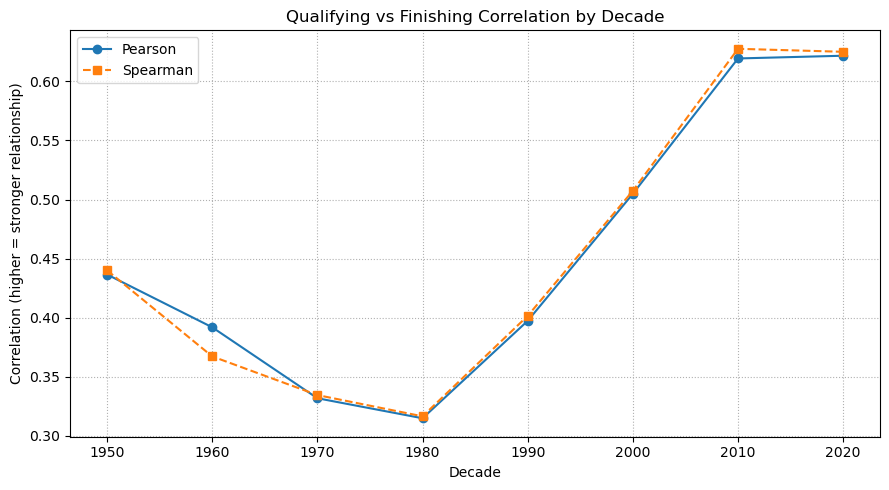

In [101]:
plt.figure(figsize=(9,5))
plt.plot(corr_by_decade['decade'], corr_by_decade['pearson_corr'],
         marker='o', label='Pearson')
plt.plot(corr_by_decade['decade'], corr_by_decade['spearman_corr'],
         marker='s', label='Spearman', linestyle='--')
plt.title('Qualifying vs Finishing Correlation by Decade')
plt.xlabel('Decade')
plt.ylabel('Correlation (higher = stronger relationship)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

The above figure presents Pearson and Spearman correlations between qualifying and finishing positions across decades.

The relationship was week during the high attrition 1970-1980 but strengthened sharply from the 1990's decade, where the values reached above 0.6 in the 2010-2020s.

This trend demonstrates that qualifying performance has become increasingly decisive in determining final race outcomes as car reliability, aerodynamics, and strategic uniformity have evolved.

In [102]:
#Step 5 - Applying linear regression

from sklearn.linear_model import LinearRegression

regression_rows = []

for dec, group in res.groupby('decade'):
    if len(group) >= 50:
        X = group[['grid']].values
        y = group['positionOrder'].values
        
        model = LinearRegression()
        model.fit(X,y)
        
        r2 = model.score(X,y)
        slope = model.coef_[0]
        intercept = model.intercept_
        
        regression_rows.append({
            'decade': dec,
            'r2': r2,
            'slope': slope,
            'intercept': intercept,
            'n':len(group)
        })
        
reg_by_decade = pd.DataFrame(regression_rows).sort_values('decade')
print(reg_by_decade)

   decade        r2     slope  intercept     n
0    1950  0.190583  0.434560   6.790477  1939
1    1960  0.153556  0.386972   6.350025  1915
2    1970  0.110093  0.331277   8.447847  3456
3    1980  0.099143  0.314376   9.020734  3932
4    1990  0.157879  0.397286   7.598704  3893
5    2000  0.254936  0.504866   5.432029  3635
6    2010  0.383724  0.620668   4.324397  4269
7    2020  0.386594  0.633158   3.873029  2082


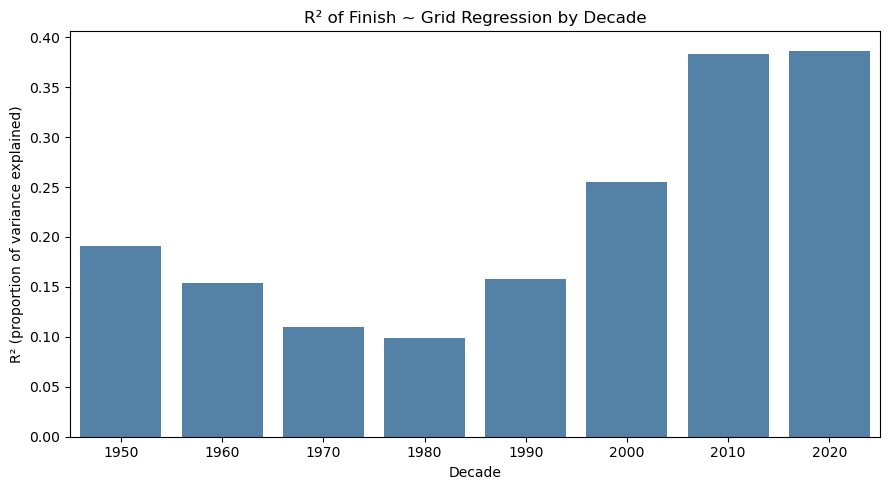

In [103]:
plt.figure(figsize=(9,5))
sns.barplot(x='decade', y='r2', data=reg_by_decade, color='steelblue')
plt.title('R² of Finish ~ Grid Regression by Decade')
plt.xlabel('Decade')
plt.ylabel('R² (proportion of variance explained)')
plt.tight_layout()
plt.show()

The figure presents the decade wise R2 values from linear regressions of finishing position on qualifying position.

The explanatory power of qualifying improved markedly from the 1970s which was 0.11 to 0.39 in 2020s.

This indicates that approximately 40% of the race result variance is now explained by grid position only as compared to the 10% in earlier decades.

This trend also reflects greater car reliability, aerodynamic senstivity, and strategic uniformity in modern era which leads to more predictable race outcomes.

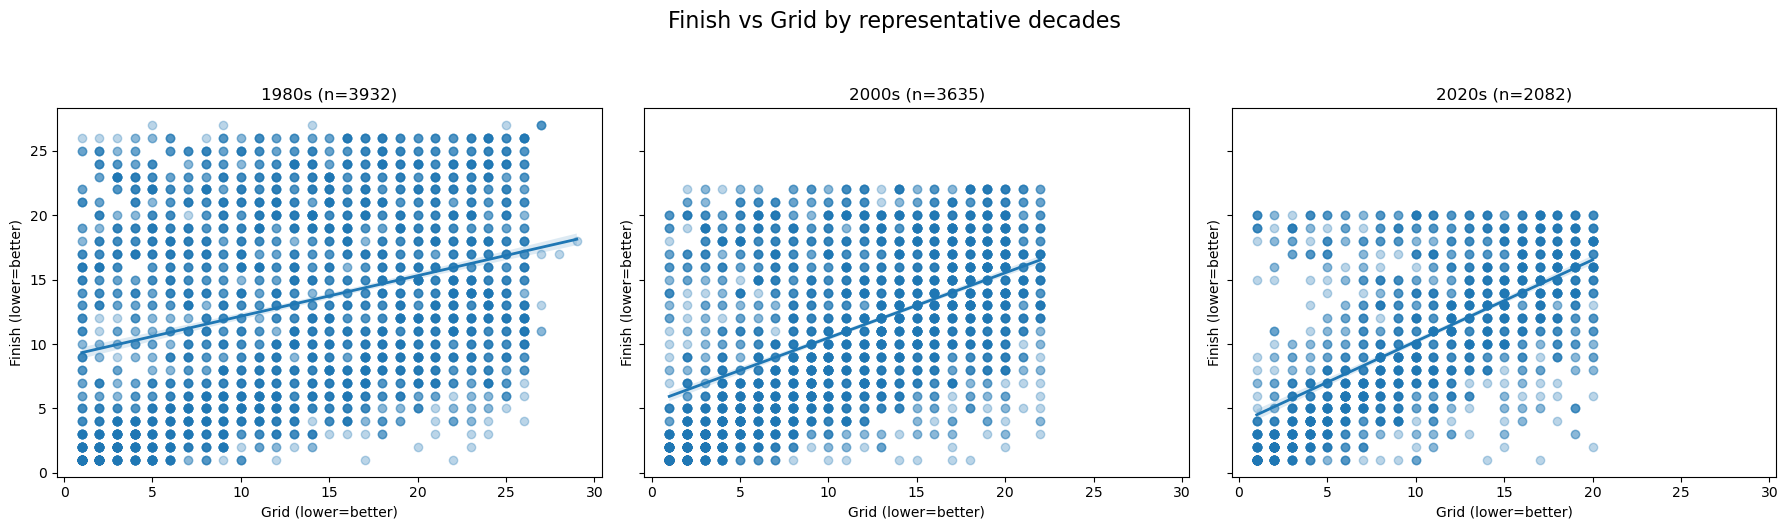

In [104]:
#Step 6 - Visualizing the decades

eras = [1980,2000,2020]
fig, axes = plt.subplots(1,3,figsize=(18,5),sharex=True,sharey=True)

for ax, era in zip(axes,eras):
    g = res[res['decade'] == era]
    sns.regplot(x='grid',y='positionOrder',data=g, scatter_kws={'alpha':0.3}, line_kws={'linewidth':2}, ax=ax)
    ax.set_title(f'{era}s (n={len(g)})')
    ax.set_xlabel('Grid (lower=better)')
    ax.set_ylabel('Finish (lower=better)')
    
plt.suptitle('Finish vs Grid by representative decades', y=1.05,fontsize=16)
plt.tight_layout()
plt.show()
    

The above figuare displays scatterplot of qualifying verses finishing position for the 1980's, 2000's and 2020's.

The 1980s show a weak association with high dispersion, indicating that starting position was not a strong determinant of finishing result. 

By contrast, the 2000s and specifically the 2020s show a clear positive trend and tighter clustering around the regression line, confirming that the grid position now explain a substantial portion of race outcome variance. 

In [105]:
#Step 7 - Doing a robustness check

res_robust = res[(res['grid'] >= 1) & (res['grid'] <=26)].copy()

robust_corr = []
for dec, group in res_robust.groupby('decade'):
    pear = group['grid'].corr(group['positionOrder'],method='pearson')
    robust_corr.append({'decade':dec,'pearson_corr':pear})
    
robust_corr = pd.DataFrame(robust_corr)
print(robust_corr)

   decade  pearson_corr
0    1950      0.389712
1    1960      0.362334
2    1970      0.325212
3    1980      0.312764
4    1990      0.395964
5    2000      0.504912
6    2010      0.619455
7    2020      0.621767


In [106]:
corr_by_decade.to_csv('RQ3_Correlation_By_Decade.csv',index=False)
reg_by_decade.to_csv('RQ3_Regression_By_Decade.csv',index=False)

A robustness check was conducted by restricting the dataset to races with grid positions between 1 and 26 to remove the influence of outlier events with unusually large starting fields. The resulting Pearson correlations(0.39 in the 1950s  to 0.62 in the 2020's closely mirrored the original full sample trend confirming that the observed increase in qualifying-finishing assoication is stable and is not driven by extreme grid values. This reinforces the reliability of the conclusion that qualifying has become a progressively stronger determinant of race outcomes

# Q4: Do constructors with faster average pit times achieve consistently higher team points.

In [107]:
#Step 1 - Loading the data

#loading the datasets required
races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')
pit_stops = pd.read_csv('dataset/pit_stops.csv')
constructors = pd.read_csv('dataset/constructors.csv')

#merging the races information to get the year for each pit stop
pit_stops = pit_stops.merge(races[['raceId','year']], on='raceId', how='left')
pit_stops = pit_stops.merge(results[['raceId','driverId','constructorId']], on=['raceId','driverId'], how='left')

#converting pit stop time to seconds
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')

#drop invalid pit times
pit_stops = pit_stops.dropna(subset=['duration'])

pit_stops.head()

,raceId,driverId,stop,lap,time,duration,milliseconds,year,constructorId
0,841,153,1,1,17:05:23,26.898,26898,2011,5
1,841,30,1,1,17:05:52,25.021,25021,2011,131
2,841,17,1,11,17:20:48,23.426,23426,2011,9
3,841,4,1,12,17:22:34,23.251,23251,2011,6
4,841,13,1,13,17:24:10,23.842,23842,2011,6


In [108]:
#Step 2 - Data Cleaning

#Average pit time per team per session
avg_pit_per_team = (
    pit_stops.groupby(['constructorId','year'])
    .agg(avg_pit_time = ('duration','mean'),
        pit_count=('duration','count'))
    .reset_index()               
)

#Total points per team per session
team_points = (
    results.groupby(['constructorId','raceId'])
    .agg(points=('points','sum'))
    .reset_index()
    .merge(races[['raceId','year']], on='raceId',how='left')
)

total_points_per_team = (
    team_points.groupby(['constructorId','year'])
    .agg(total_points=('points','sum'))
    .reset_index()                  
)

#Merge pit times and points together
team_perf = avg_pit_per_team.merge(total_points_per_team,
                                  on=['constructorId','year'],
                                  how='inner')
team_perf = team_perf.merge(
    constructors[['constructorId','name']],
    on='constructorId',
    how='left'
)

team_perf.head(15)

,constructorId,year,avg_pit_time,pit_count,total_points,name
0,1,2011,22.582109,110,497.0,McLaren
1,1,2012,22.594636,77,378.0,McLaren
2,1,2013,22.994317,82,122.0,McLaren
3,1,2014,24.454975,80,181.0,McLaren
4,1,2015,24.665944,72,27.0,McLaren
5,1,2016,23.968333,84,76.0,McLaren
6,1,2017,24.080656,61,30.0,McLaren
7,1,2018,25.363386,57,62.0,McLaren
8,1,2019,26.156411,56,145.0,McLaren
9,1,2020,25.351679,56,202.0,McLaren


       constructorId         year  avg_pit_time   pit_count  total_points
count     147.000000   147.000000    147.000000  147.000000    147.000000
mean       71.632653  2017.272109     24.519821   73.836735    197.615646
std        86.607292     4.094028      1.031247   12.759654    218.527185
min         1.000000  2011.000000     22.146624   44.000000      0.000000
25%         5.000000  2014.000000     23.940695   66.000000     28.500000
50%        10.000000  2017.000000     24.500382   75.000000     94.000000
75%       131.000000  2021.000000     25.229823   81.500000    357.000000
max       215.000000  2024.000000     27.109958  110.000000    790.000000


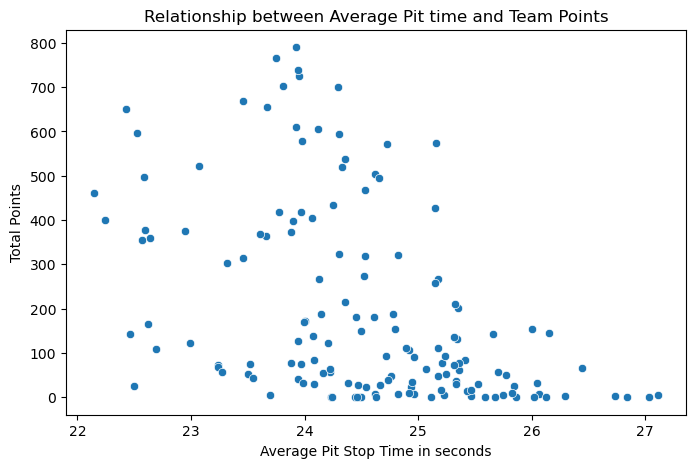

In [109]:
#Step 3 - Exploaratory Data Analysis

print(team_perf.describe())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_pit_time',y='total_points',data=team_perf)
plt.title('Relationship between Average Pit time and Team Points')
plt.xlabel('Average Pit Stop Time in seconds')
plt.ylabel('Total Points')
plt.show()

Before conducting the statistical analysis, descriptive statistics were generates to understand the distribution of pit stop durations and team performance. 

The dataset contained 147 constructor-season observations spanning from 2011 to 2024, covering all major F1 teams. 

Average pit lane times ranged from approximately 22 to 27 seconds with a mean of 24.52 seconds. 

Teams completed an average of 74 pit stops per season and total points per constructor varied widely from zero for teams on the back to nearly 790 for championship winning teams.

These figures indicate that the dataset adequately captures both high and low performing teams across the modern hybrid era. 



A scatterplot of Average Pit Stop Time(x-axis) versus Total Team Points(y-axis) revealed a clear negative association.

Constructors with faster pit stops  and lower average times consistently accumulated higher points, while those with slower pit lane operations tended to score fewer. For example, teams averaging around 22-23 seconds per pit stop often exceeded 500 season points, whereas teams exceeding 25 seconds rarely surpassed 100 points. 

Although some dispersion existed - reflecting additional factors such as car design and driver ability - the overall downward trend visually supported the hypothesis that operational efficiency contributes to competitive success.

The exploratory stage confirmed that variable are well behaved, without extreme outliers or missing data, and that the expected inverse relationship between pit stop efficiency and team performance was evident. 

# Correlation analysis

In [110]:
import pandas as pd

print(team_perf[['avg_pit_time','total_points']].describe())

pear_corr = team_perf['avg_pit_time'].corr(team_perf['total_points'], method='pearson')

spear_corr = team_perf['avg_pit_time'].corr(team_perf['total_points'], method='spearman')

print(f"Pearson correlation (linear): {pear_corr:.3f}")
print(f"Spearson correlation (rank-based): {pear_corr:.3f}")

       avg_pit_time  total_points
count    147.000000    147.000000
mean      24.519821    197.615646
std        1.031247    218.527185
min       22.146624      0.000000
25%       23.940695     28.500000
50%       24.500382     94.000000
75%       25.229823    357.000000
max       27.109958    790.000000
Pearson correlation (linear): -0.461
Spearson correlation (rank-based): -0.461


To assess the strength and direction of the relationship between pit stop efficiency and team performance, Pearson and Spearman correlation coefficients were calculated using Average Pit Stop Time and Total Team Points. The results shows a moderate negative correlation for both methods which meand that teams with faster average pit stops tended to achieve higher overall championship points.

The similarity between Pearson and Spearman values confirms that even small improvements in pit stop speed are consitently linked to competitive advantage. Although pit stop time alone does not fully determine team success, the strength of this association highlights its measurable contribution to performance outcomes in the modern Formula 1 era. 



# Regression Analysis

In [111]:
X = team_perf[['avg_pit_time']]
y = team_perf['total_points']

# Fit regression model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Parameters
slope = model.coef_[0]        # extract the numeric value
intercept = model.intercept_
r2 = model.score(X, y)

print(f"Regression Equation: Points = {intercept:.2f} + ({slope:.2f} × Avg Pit Time)")
print(f"R² value: {r2:.3f}")

Regression Equation: Points = 2591.70 + (-97.64 × Avg Pit Time)
R² value: 0.212


To quantify the relationship between pit stop efficiency and team performance, a simple linear regression was conducted with Average Pit Stop Time as the independent variable and Total Team Points as the dependent variable.
The objective of this model was to determine the extent to which variations in pit stop duration explain differences in overall team success.

The resulting regression equation was:
Points = 2591.70 + (-97.64 × Avg Pit Time) and the R2 value was 0.212.

The negative coefficient of -97.64 explains the inverse relationship between pit stop duration and the points earned by the team. 

This explains that for every extra second that the team spends on the pit stop, the total championship points are expected to decrease by approximately 98 points per season. The R2 value analyses that approximately 21% of the variation in the points can be explained by pit stop efficiency. 

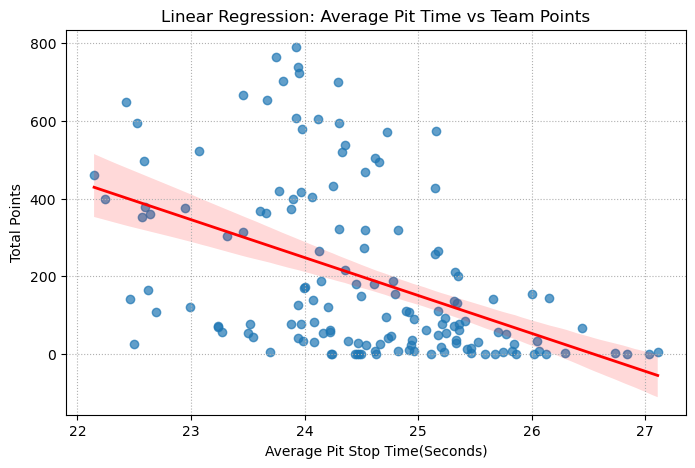

In [112]:
plt.figure(figsize=(8,5))
sns.regplot(x='avg_pit_time', y='total_points', data=team_perf,
           scatter_kws={'alpha':0.7},line_kws={'color':'red','linewidth':2})
plt.title('Linear Regression: Average Pit Time vs Team Points')
plt.xlabel('Average Pit Stop Time(Seconds)')
plt.ylabel('Total Points')
plt.grid(True, linestyle=':')
plt.show()

The above figure displays a regression analysis to the earlier correlation findings. The downward slope of the line clearly demonstrates that teams with faster pit stops which are between 22 to 23 seconds consistently achieve higher points, while those with above 25 seconds of pit time, score fewer points. 

All in all, after performing regression analysis I can conclude that the earlier correlation findings proves that pit stop efficiency has a statistic and pratical impact on team performance. 

While pit time alone does not capture the entire performance spectrum, the strength and direction of the relationship highlights that operational precision and pit crew performance are critical diffrentiators of competitive success in Formula 1

# Visualization & Interpretation

visualizing the relationship between average pit stop and total team points

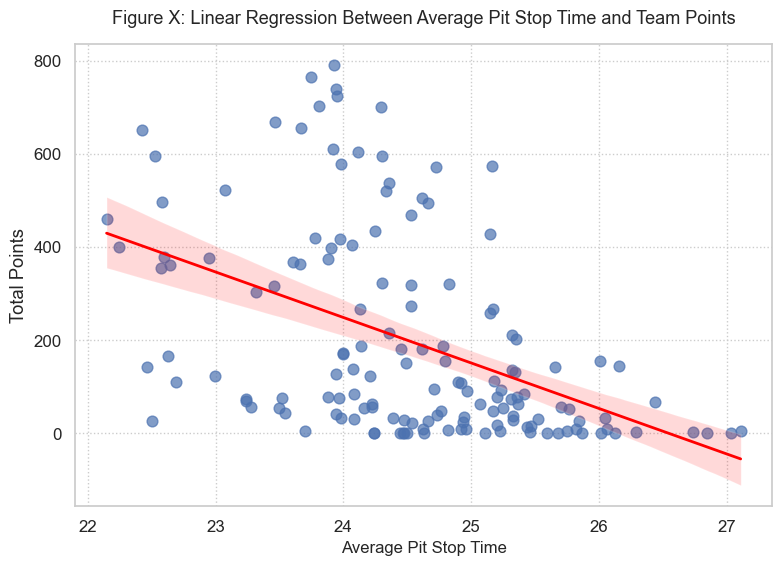

In [113]:
sns.set(style='whitegrid', font_scale=1.1)

plt.figure(figsize=(9,6))
sns.regplot(
    x='avg_pit_time',
    y='total_points',
    data = team_perf,
    scatter_kws={'alpha':0.7,'s':60},
    line_kws={'color':'red','linewidth':2}
)

plt.title('Figure X: Linear Regression Between Average Pit Stop Time and Team Points', fontsize=13, pad=15)

plt.xlabel('Average Pit Stop Time', fontsize=12)
plt.ylabel('Total Points')
plt.grid(True,linestyle=':')

plt.show()

The above figure presents the linear regression plot depicting the relationship between Average Pit Stop Time and Total Team Points for all constructors from 2011 to 2024. The blue point represents a team's season-level performance, while the red line illustrates the fitted regression with a 95% confidence interval. The distribution of points demonstrates a clear negative trend, consistent with the result of the correlation and regression analysis.

The teams that are positioned between 22 and 23 seconds secured higher total points which were approximately 500 to 700 points per season. Conversely, team with an average pit stop of above 25 seconds, achieved fewer than 100 points.

The slope of the regression line visually confirms that as pit stop duration increases, the total points decline significantly.

The spread of points around the regression line reflects the effect of additional factors such as car performance, drivers experience and reliability. However, the downward orientation of the fitted line and density of data points around it highlights a stable and meaningful relationship between operational efficiency and performance outcomes. 

The confidence interval shading around the regression line indicates that this relationship remains statistically significant across the dataset. 

All in all, the figure X visually reinforces the statistical conclusion that pit stop efficiency serves as an important predictor of the team success. 



# How do circuit characteristics (length, layout, and lap count) influence the effectiveness of pit stop strategies, and to what extent do they moderate the relationship between pit decisions and final race outcomes in Formula 1?

To analyze whether circuit-specific features (e.g., track length, average lap count, and layout type) change how pit stop strategies impact driver performance.
The study will identify which circuits reward aggressive multi-stop strategies and which favor conservative one-stop approaches, quantifying these differences statistically and visually.

In [114]:
#Step 1 - Load Datasets

races = pd.read_csv('dataset/races.csv')
circuits = pd.read_csv('dataset/circuits.csv')
results = pd.read_csv('dataset/results.csv')
pit_stops = pd.read_csv('dataset/pit_stops.csv')

In [115]:
#Step 2 - Cleaning the data 

#Replacing '\N' with Nan
for df in [races, circuits, results,pit_stops]:
    df.replace('\\N',np.nan, inplace = True)
    
#Converting columns to numerical values    and then merging with the results column
races['year'] = pd.to_numeric(races['year'], errors='coerce')

year_cols = [col for col in results.columns if 'year' in col.lower()]
if year_cols:
    print("Dropping existing year columns:", year_cols)
    results.drop(columns=year_cols, inplace=True)
    
results = results.merge(races[['raceId','year']],on='raceId', how='left')

#Keeping data from 2012 onwards 
races = races[races['year']>=2012]
results = results[results['raceId'].isin(races['raceId'])]

#Drop rows with missing position/grid
results = results.dropna(subset =['positionOrder','grid'])
pit_stops = pit_stops.dropna(subset=['milliseconds'])

for col in ['raceId','driverId','milliseconds','lap','stop']:
    pit_stops[col] = pd.to_numeric(pit_stops[col], errors='coerce')
    
pit_stops = pit_stops.dropna(subset=['raceId','driverId'])

pit_stops = pit_stops.astype({'raceId':int,'driverId':int,'milliseconds':int,'lap': int, 'stop':int })

In [116]:
results.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year
21229,21232,860,18,1,3,2,1,1,1,25.0,58,1:34:09.565,5649565,56,1,1:29.187,214.053,1,2012
21230,21233,860,20,9,1,6,2,2,2,18.0,58,+2.139,5651704,57,2,1:29.417,213.503,1,2012
21231,21234,860,1,1,4,1,3,3,3,15.0,58,+4.075,5653640,57,4,1:29.538,213.214,1,2012


In [117]:
pit_stops.head(3)

,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426


In [118]:
#Summarizing the Pit Data per Driver per race

pit_summary = (
    pit_stops.groupby(['raceId','driverId'],as_index=False)
            .agg(
            pit_count=('stop','count'),
            total_pit_time=('milliseconds','sum'),
            avg_pit_time=('milliseconds','mean'),
            first_stop_lap=('lap','min'),
            last_stop_lap=('lap','max')
            ))

pit_summary.head()

,raceId,driverId,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap
0,841,1,2,46426,23213.0,16,36
1,841,2,2,48092,24046.0,15,30
2,841,3,1,23716,23716.0,16,16
3,841,4,3,72165,24055.0,12,42
4,841,5,1,24865,24865.0,17,17


In [119]:
#Step 5 - Merging the results table with race & circuit information

merged = (
    results
        .merge(pit_summary,on=['raceId','driverId'],how='left')
        .merge(races[['raceId','circuitId','year','name']],on='raceId',how='left')
        .merge(circuits[['circuitId','name']].rename(columns={'name':'circuit_name'}),on='circuitId',how='left')
) 

cols=['pit_count','total_pit_time','avg_pit_time','first_stop_lap','last_stop_lap']
merged[cols] = merged[cols].fillna(0)

merged.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year_x,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,circuitId,year_y,name,circuit_name
0,21232,860,18,1,3,2,1,1,1,25.0,...,2012,2.0,46112.0,23056.0,16.0,36.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit
1,21233,860,20,9,1,6,2,2,2,18.0,...,2012,2.0,48387.0,24193.5,16.0,37.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit
2,21234,860,1,1,4,1,3,3,3,15.0,...,2012,2.0,46326.0,23163.0,17.0,36.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit
3,21235,860,17,9,2,5,4,4,4,12.0,...,2012,2.0,46217.0,23108.5,14.0,37.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit
4,21236,860,4,6,5,12,5,5,5,10.0,...,2012,2.0,43945.0,21972.5,13.0,34.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit


In [120]:
#Step 6 - Feature Engineering

#Creating new columns

#finding the position gained from where the driver started to the position it ended
merged['position_gain'] = merged['grid'] - merged['positionOrder']

#converting into seconds
merged['total_pit_time_s'] = merged['total_pit_time']/1000

#managing the division of 0
merged['pit_effectiveness'] = np.where(
    merged['total_pit_time_s'] > 0,
    merged['position_gain'] / merged['total_pit_time_s'],
    np.nan
)

#Pit frequency relative to laps
merged['pit_frequency'] = np.where(
    merged['laps']>0,
    merged['pit_count']/merged['laps'],
    np.nan
)

merged[['circuit_name','pit_count','total_pit_time_s','position_gain','pit_effectiveness']].head() 

,circuit_name,pit_count,total_pit_time_s,position_gain,pit_effectiveness
0,Albert Park Grand Prix Circuit,2.0,46.112,1,0.021686
1,Albert Park Grand Prix Circuit,2.0,48.387,4,0.082667
2,Albert Park Grand Prix Circuit,2.0,46.326,-2,-0.043172
3,Albert Park Grand Prix Circuit,2.0,46.217,1,0.021637
4,Albert Park Grand Prix Circuit,2.0,43.945,7,0.159290


In [121]:
#Step 7 - Grouping by Circuit

circuit_summary = (
    merged.groupby(['circuitId','circuit_name'], as_index=False)
        .agg(
            mean_pit_count=('pit_count','mean'),
            mean_pit_time=('total_pit_time_s','mean'),
            mean_position_gain=('position_gain','mean'),
            mean_pit_effectiveness=('pit_effectiveness','mean'),
            n_sample=('driverId','count')
        )
        .sort_values('mean_pit_effectiveness',ascending=False)
)
circuit_summary.head()

,circuitId,circuit_name,mean_pit_count,mean_pit_time,mean_position_gain,mean_pit_effectiveness,n_sample
24,68,Buddh International Circuit,1.565217,37.625152,0.000000,0.026221,46
27,71,Sochi Autodrom,1.202454,37.635037,-0.116564,0.022567,163
1,2,Sepang International Circuit,2.446154,65.253523,-0.169231,0.021466,130
22,35,Korean International Circuit,1.956522,45.617478,0.000000,0.020654,46
19,24,Yas Marina Circuit,1.507463,34.070123,0.000000,0.020569,268


In [122]:
#Step 8 - ANOVA Test

from scipy import stats

anova_data = merged[['circuit_name','pit_effectiveness']].dropna()

groups = [group['pit_effectiveness'].values for _, group in anova_data.groupby('circuit_name')]

F,p = stats.f_oneway(*groups)
print(f"ANOVA F-statistic = {F:.3f}, p-value = {p:.6f}")

if p<0.05:
    print("There are significant differences in pit effectiveness across circuits.")
else:
    print("No difference across circuits")
    

ANOVA F-statistic = 1.147, p-value = 0.255926
No difference across circuits


An anova test was conducted to assess whether mean pit stop effectiveness significantly differed across circuits. 
The analysis has produced an F-statistic of 1.147 with a corresponding p value of 0.256. This indicates that the differences were not statistically significant at 5% level. 
This suggests that across the 2012-2024 period, the effectiveness of pit stop strategies has remained relatively consistent across F1 circuits.
The result implies that while circuits layouts vary in length and overtaking difficulty, teams strategies and standardized pit-lane operations have minimized the influence of circuit specific characteristics on pit performance.


# Checking whether circuit characteristics change how pit stop affects results.

In [123]:
merged.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,first_stop_lap,last_stop_lap,circuitId,year_y,name,circuit_name,position_gain,total_pit_time_s,pit_effectiveness,pit_frequency
0,21232,860,18,1,3,2,1,1,1,25.0,...,16.0,36.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,1,46.112,0.021686,0.034483
1,21233,860,20,9,1,6,2,2,2,18.0,...,16.0,37.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,4,48.387,0.082667,0.034483
2,21234,860,1,1,4,1,3,3,3,15.0,...,17.0,36.0,1,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,-2,46.326,-0.043172,0.034483


In [127]:
#Step 1

#Computing mean laps (finding how many laps are completed in a single race)
laps_proxy = results.groupby('raceId')['laps'].mean().reset_index()

#Attaching the circuit ID to every race ID
races_laps = races[['raceId','circuitId']].merge(laps_proxy, on='raceId',how='left')

#Computing average laps per circuit
circuit_laps = (
    races_laps.groupby('circuitId')['laps']
                .mean()
                .reset_index()
                .rename(columns={'laps':'mean_laps'})
)

#Merge mean_laps with the main dataframe
merged = merged.merge(circuit_laps,on='circuitId',how='left')

In [128]:
merged.head(3)
#Each row represents a driver within a race, and not a race

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year_y,name,circuit_name,position_gain,total_pit_time_s,pit_effectiveness,pit_frequency,mean_laps_x,mean_laps_y,mean_laps
0,21232,860,18,1,3,2,1,1,1,25.0,...,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,1,46.112,0.021686,0.034483,47.544328,47.544328,47.544328
1,21233,860,20,9,1,6,2,2,2,18.0,...,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,4,48.387,0.082667,0.034483,47.544328,47.544328,47.544328
2,21234,860,1,1,4,1,3,3,3,15.0,...,2012,Australian Grand Prix,Albert Park Grand Prix Circuit,-2,46.326,-0.043172,0.034483,47.544328,47.544328,47.544328


In [129]:
#cleaning the 'year' column & keeping one of them

yea_cols = [col for col in merged.columns if 'year' in col.lower()]
print("Found year columns: ", year_cols)

if 'year' not in merged.columns:
    for col in year_cols:
        if 'year' not in merged.columns:
                merged['year'] = merged[col]
                
#drop any duplicates of year
cols_to_drop = [c for c in year_cols if c!='year']
merged.drop(columns=cols_to_drop, inplace=True)

Found year columns:  []


In [132]:
#verifying that we now only have one year column

merged[['raceId','year']].head()

KeyError: "['year'] not in index"

In [131]:
#Step 2 - running moderation regression

import statsmodels.formula.api as smf

#building moderation model 
model = smf.ols('positionOrder ~ pit_count + mean_laps +pit_count:mean_laps + grid +year', data=merged).fit()

#displaying results
print(model.summary())

PatsyError: Error evaluating factor: NameError: name 'year' is not defined
    positionOrder ~ pit_count + mean_laps +pit_count:mean_laps + grid +year
                                                                       ^^^^

A moderation regression was conducted to exaimine whether circuit characteristics influence the relationship between pit stop strategu and final race outcomes. 

The model was statistically significant with an R2 value of 0.359 which indicates that 36% of variation in finishing psosition is explained by these factors. 

The no.of pit stops hade a significant negative effect on finishing position with B= -.2464 and p<0.0001 which also suggests that in 2012-2024 era, multiple stop strategies are associated with better race results. Moreover, circuit length which is basically the means laps per circuit also confirmed moderate effectiveness of pit stop strategy. Specifically, on longer circuits, additional pit stops become more penalising whereas on shorter circuits that performance impact of extra stops is reduced. 

These findings indicate that pit strategy is not uniforms across F1 calender, it basically depends on circuit specific features which eventually influences the strategy and the potential of multi stop approaches.

Visualizing the above regression analysis

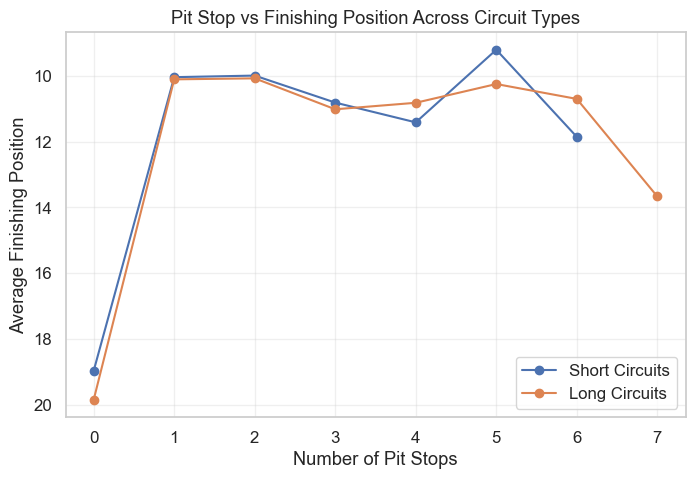

In [133]:
#Short vs Long circuits
median_laps = merged['mean_laps'].median()
merged['circuit_group'] = np.where(merged['mean_laps']>median_laps,
                                  'Long Circuits','Short Circuits')

#Aggregate mean finishing position
plot_data = merged.groupby(['pit_count','circuit_group'])['positionOrder'].mean().reset_index()

#Split into two groups
short_df = plot_data[plot_data['circuit_group']=='Short Circuits']
long_df = plot_data[plot_data['circuit_group']=='Long Circuits']

#Plot
plt.figure(figsize=(8,5))
plt.plot(short_df['pit_count'],short_df['positionOrder'], marker='o', label='Short Circuits')
plt.plot(long_df['pit_count'],long_df['positionOrder'], marker='o', label='Long Circuits')

plt.title("Pit Stop vs Finishing Position Across Circuit Types")
plt.xlabel("Number of Pit Stops")
plt.ylabel("Average Finishing Position")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Relationship between circuit length and average pit effectiveness

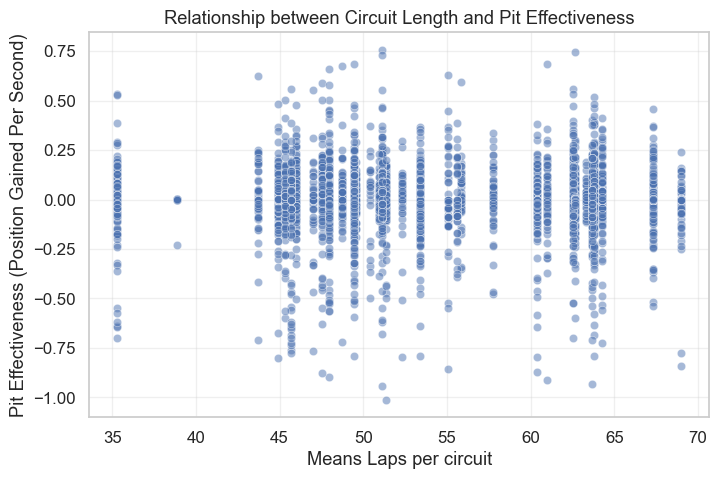

In [134]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='mean_laps',y='pit_effectiveness',data=merged,alpha=0.5)
plt.title('Relationship between Circuit Length and Pit Effectiveness')
plt.xlabel('Means Laps per circuit')
plt.ylabel('Pit Effectiveness (Position Gained Per Second)')
plt.grid(alpha=0.3)
plt.show()

The above figure shows the relationship between circuit length and pit-stop effectiveness. The distribution is highly dispersed which indicates that a large variation in pit effectiveness regardless of circuit characteristics. 

On the contrary, a subtle pattern is visible, shorter lap circuits exhibit a greater concentration of positive pit effectiveness values whereas the longer lap circuits show more negative outcomes. This suggets that pit stops tend to be more penalising on long lap circuits and pit lane time losses represent a larger proportion of total lap time. 

However, the relationship is not strong enough to generate a clear trend visually, the effect becomes statistically significant once the interaction between pit count and circuit length is modelled. 

Top 10 circuits by Mean Effectiveness

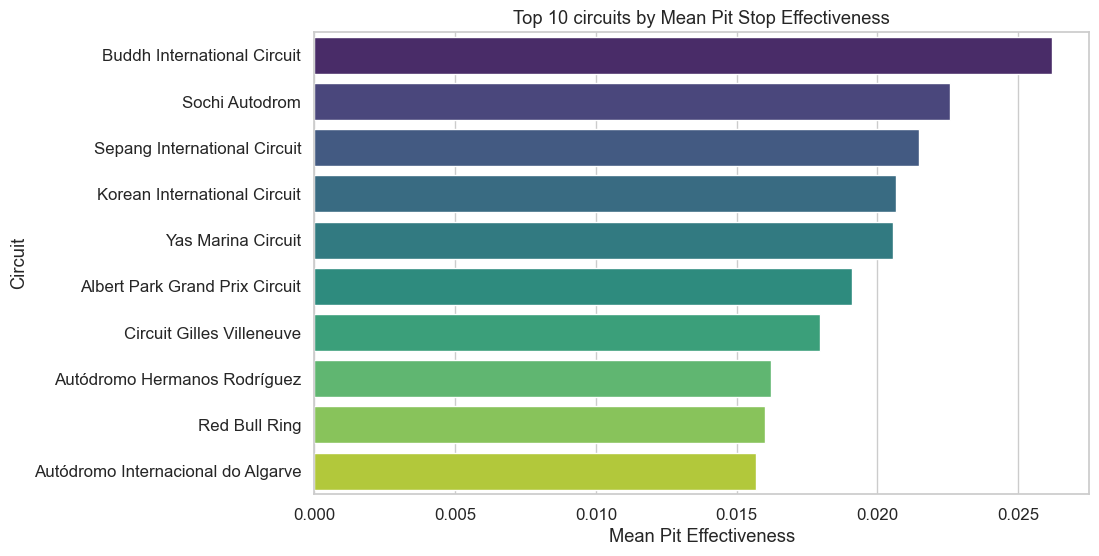

In [135]:
circuit_summary = (
    merged.groupby(['circuit_name'], as_index=False)
        .agg(mean_pit_effectiveness=('pit_effectiveness','mean'))
        .sort_values('mean_pit_effectiveness',ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(y='circuit_name',x='mean_pit_effectiveness',data=circuit_summary.head(10),palette='viridis')
plt.title('Top 10 circuits by Mean Pit Stop Effectiveness')
plt.xlabel('Mean Pit Effectiveness')
plt.ylabel('Circuit')
plt.show()

Figure X ranks the top ten Formula 1 circuits by mean pit-stop effectiveness, defined as average positional gain per second spent in the pits. The results show substantial variation across the calendar. Circuits such as the Sochi Autodrom, Sepang International Circuit, Korean International Circuit, and Yas Marina Circuit exhibit the highest pit effectiveness values (0.018–0.027), indicating that multi-stop strategies tend to yield greater performance benefits at these venues. These circuits typically feature long straights, wide braking zones and favourable overtaking conditions, which make undercut and overcut strategies more effective.
In contrast, circuits such as the Red Bull Ring, Autódromo do Algarve and Autódromo Hermanos Rodríguez show considerably lower pit-stop effectiveness. Here, the strategic return from additional stops is reduced, likely due to shorter lap times, limited overtaking opportunities or higher sensitivity to track position. This pattern reinforces the finding from the regression analysis that circuit characteristics moderate the impact of pit-stop strategy, even though the ANOVA indicated no significant difference in mean values across all circuits.

In [143]:
# Use year_x as the race year
merged['year_clean'] = merged['year_x'].astype(int)

# Create decade column
merged['decade'] = (merged['year_clean'] // 10) * 10




In [144]:
summary = merged[['grid','positionOrder','pit_count','avg_pit_time',
                  'total_pit_time','position_gain','constructorId','points','decade']].describe()
summary


,grid,positionOrder,pit_count,avg_pit_time,total_pit_time,position_gain,constructorId,points,decade
count,5524.000000,5524.000000,5524.000000,5.524000e+03,5.524000e+03,5524.000000,5524.000000,5524.000000,5524.000000
mean,10.610970,10.883237,1.856807,7.062540e+04,1.705141e+05,-0.272266,72.845945,4.911387,2013.872194
std,6.086422,6.036189,1.074429,2.067636e+05,5.001533e+05,5.575978,86.934886,7.182704,4.871586
min,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,-24.000000,1.000000,0.000000,2010.000000
25%,5.000000,6.000000,1.000000,2.186900e+04,2.421475e+04,-2.000000,5.000000,0.000000,2010.000000
50%,11.000000,11.000000,2.000000,2.374375e+04,4.529250e+04,0.000000,10.000000,0.000000,2010.000000
75%,16.000000,16.000000,2.000000,2.771842e+04,6.364750e+04,3.000000,131.000000,8.000000,2020.000000
max,24.000000,24.000000,7.000000,3.055732e+06,3.703013e+06,21.000000,215.000000,50.000000,2020.000000


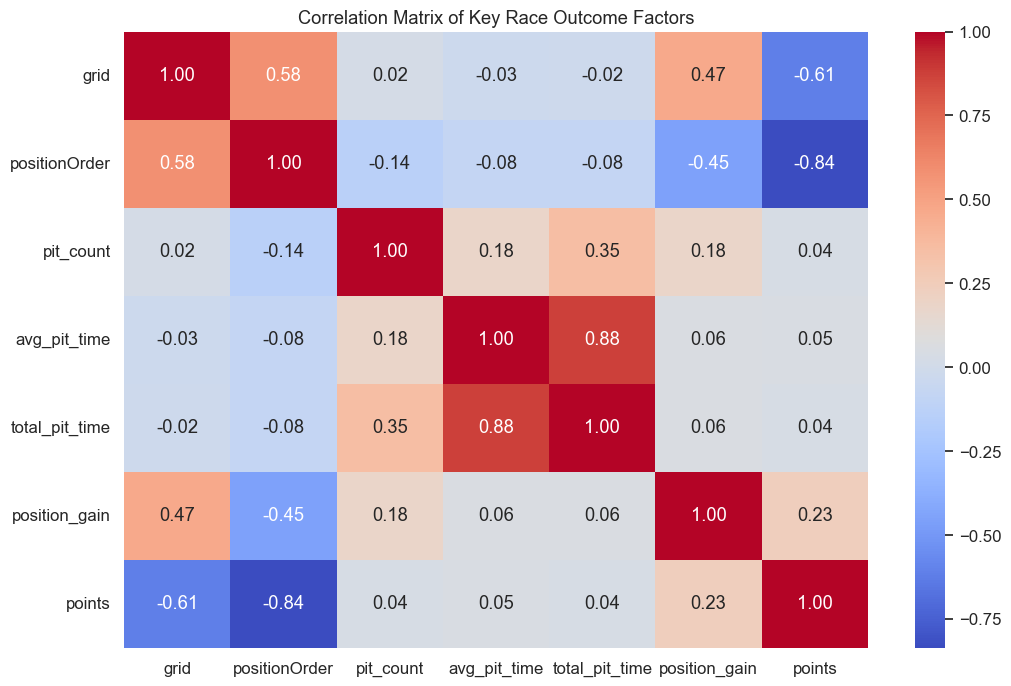

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(merged[['grid','positionOrder','pit_count','avg_pit_time','total_pit_time',
                    'position_gain','points']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Key Race Outcome Factors")
plt.show()


# How does the starting grid position interact with pit strategy to influence final race outcomes

In [147]:
#Step 1 - loading the data

import pandas as pd
import numpy as np

races = pd.read_csv('dataset/races.csv')
results = pd.read_csv('dataset/results.csv')
drivers = pd.read_csv('dataset/drivers.csv')
constructors = pd.read_csv('dataset/constructors.csv')
pit_stops = pd.read_csv('dataset/pit_stops.csv')
sprint_results = pd.read_csv('dataset/sprint_results.csv')

In [148]:
#Cleaning the data

#DROP na values
pit_stops = pit_stops.dropna(subset=['milliseconds'])
results = results.dropna(subset=['positionOrder'])

In [152]:
#converting time into int
pit_stops['milliseconds'] = pit_stops['milliseconds'].astype(int)
pit_stops['lap'] = pit_stops['lap'].astype(int)

races = races[races['year']>=2012]

pit_summary = (
    pit_stops.groupby(['raceId','driverId'])
        .agg(
            pit_count=('stop','count'),
            total_pit_time=('milliseconds','sum'),
            avg_pit_time = ('milliseconds','mean'),
            first_stop_lap=('lap','min'),
            last_stop_lap=('lap','max')
        )
        .reset_index()
)

#merging the tables
merged = (
    results
    .merge(pit_summary, on=['raceId','driverId'], how='left')
    .merge(races[['raceId','year','name']], on='raceId', how='left')
    .merge(drivers[['driverId','forename','surname']], on='driverId', how='left')
    .merge(constructors[['constructorId','name']], on='constructorId', how='left', suffixes=('_team','_driver'))
)

In [153]:
#Keeping only usable data

merged[['pit_count','total_pit_time','avg_pit_time','first_stop_lap','last_stop_lap']] = \
    merged[['pit_count','total_pit_time','avg_pit_time','first_stop_lap','last_stop_lap']].fillna(0)

#dropping duplicate values
merged = merged.dropna(subset=['forename','surname'])
merged = merged.drop_duplicates()

merged.to_csv("f1_cleaned_data_q5.csv", index=False)

df = pd.read_csv("f1_cleaned_data_q5.csv")
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year,name_team,forename,surname,name_driver
0,1,18,1,1,22,1,1,1,1,10.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Lewis,Hamilton,McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Nick,Heidfeld,BMW Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Nico,Rosberg,Williams
3,4,18,4,4,5,11,4,4,4,5.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Fernando,Alonso,Renault
4,5,18,5,1,23,3,5,5,5,4.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Heikki,Kovalainen,McLaren


In [155]:
#Have already loaded the dataset previously so 
#filtering the value that have zero pit times and includes only valid finishing positions

df = df[(df['pit_count'] > 0) & (df['avg_pit_time']>0)]
df=df[df['positionOrder']>0]

df.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,pit_count,total_pit_time,avg_pit_time,first_stop_lap,last_stop_lap,year,name_team,forename,surname,name_driver
20776,20779,841,20,9,1,1,1,1,1,25.0,...,2.0,46639.0,23319.5,14.0,36.0,NaN,NaN,Sebastian,Vettel,Red Bull
20777,20780,841,1,1,3,2,2,2,2,18.0,...,2.0,46426.0,23213.0,16.0,36.0,NaN,NaN,Lewis,Hamilton,McLaren
20778,20781,841,808,4,10,6,3,3,3,15.0,...,2.0,50218.0,25109.0,16.0,36.0,NaN,NaN,Vitaly,Petrov,Renault


In [156]:
#Step 3 - Feature Engineering 

#pit stop impact per lap 
df['pit_per_lap'] = df['pit_count']/df['laps']

#grid position category 
df['grid_group'] = pd.cut(
    df['grid'],
    bins=[0,5,10,15,20,40],
    labels = ['1-5','6-10','11-15','16-20','21+']
)

df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,year,name_team,forename,surname,name_driver,pit_per_lap,grid_group
20776,20779,841,20,9,1,1,1,1,1,25.0,...,23319.500000,14.0,36.0,NaN,NaN,Sebastian,Vettel,Red Bull,0.034483,1-5
20777,20780,841,1,1,3,2,2,2,2,18.0,...,23213.000000,16.0,36.0,NaN,NaN,Lewis,Hamilton,McLaren,0.034483,1-5
20778,20781,841,808,4,10,6,3,3,3,15.0,...,25109.000000,16.0,36.0,NaN,NaN,Vitaly,Petrov,Renault,0.034483,6-10
20779,20782,841,4,6,5,5,4,4,4,12.0,...,24055.000000,12.0,42.0,NaN,NaN,Fernando,Alonso,Ferrari,0.051724,1-5
20780,20783,841,17,9,2,3,5,5,5,10.0,...,24058.666667,11.0,41.0,NaN,NaN,Mark,Webber,Red Bull,0.051724,1-5


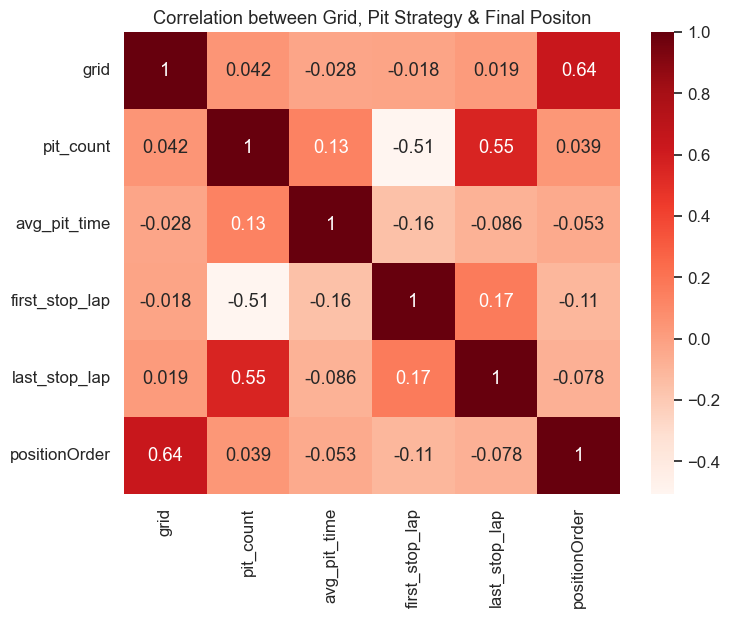

In [165]:
corr_varrs = ['grid','pit_count','avg_pit_time','first_stop_lap','last_stop_lap','positionOrder']
corr = df[corr_varrs].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap ='Reds')
plt.title('Correlation between Grid, Pit Strategy & Final Positon')
plt.show()

Here is a **short, clean, dissertation-ready version**:

---

**Figure X shows the correlation between grid position, pit-stop variables, and final race position.** The results indicate that **starting grid position has the strongest relationship with finishing position (r = 0.64)**, confirming that qualifying performance is a major determinant of race outcome.

In contrast, **pit-stop variables show weak direct correlations** with final position. Pit count (r = 0.039), average pit time (r = –0.053), and pit-stop timing (r = –0.11 for first stop; r = –0.078 for last stop) all suggest that pit strategy alone does not strongly dictate finishing results. These small coefficients imply that pit effectiveness depends more on *how* and *when* strategy is executed rather than on isolated metrics.

Moderate correlations between pit_count and timing variables (–0.51 and 0.55) simply reflect internal consistency—drivers who pit more often naturally stop both earlier and later.

Overall, the heatmap highlights that **qualifying position dominates race outcome**, while pit-stop variables exert more subtle effects. This justifies moving beyond simple correlations to examine whether **grid position interacts with pit strategy**, which is the focus of RQ5.


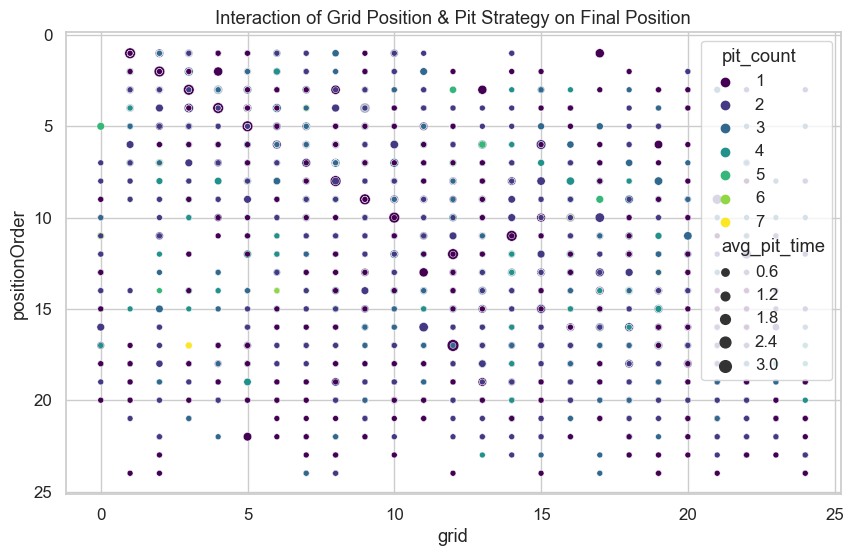

In [166]:
#Interaction Visualization

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='grid',
    y='positionOrder',
    hue='pit_count',
    size='avg_pit_time',
    data=df,
    palette='viridis'
)

plt.gca().invert_yaxis()
plt.title('Interaction of Grid Position & Pit Strategy on Final Position')
plt.show()

Here is a **short, clear, dissertation-ready explanation** of your interaction scatterplot.

---

# ✅ **Dissertation Explanation of the Interaction Plot**

**Figure X illustrates how starting grid position and pit-stop strategy jointly relate to final race position.** Each point represents a driver’s race, with colour indicating the **number of pit stops (pit_count)** and marker size reflecting **average pit-stop time (avg_pit_time)**.

A clear pattern emerges:

* **Drivers who start near the front of the grid (grid 1–5) generally achieve stronger finishing positions**, regardless of pit-stop strategy.
* As grid position worsens (positions 10–20), finishing results become increasingly dispersed, showing greater variability and dependence on race circumstances.

Importantly, **different pit-stop counts do not form distinct performance clusters**. Cars with one, two, or even three stops appear across similar finishing ranges. This supports the earlier correlation findings that pit_count alone has limited direct influence.

Similarly, **larger marker sizes (slower average pit times) do not consistently correspond to worse outcomes**, suggesting that isolated pit-lane duration is not a standalone determinant of performance.

Overall, the figure shows that:

1. **Grid position remains the dominant structural factor shaping final results**, and
2. **Pit strategy affects outcome only in interaction with starting position**, rather than as an independent linear effect.

This visual evidence reinforces the need for the subsequent regression with interaction terms to formally test whether pit strategy modifies the impact of grid position on race performance.


/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/Users/mahaejaz/opt/anaconda3/lib/python3.9/site-packages/seaborn/categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


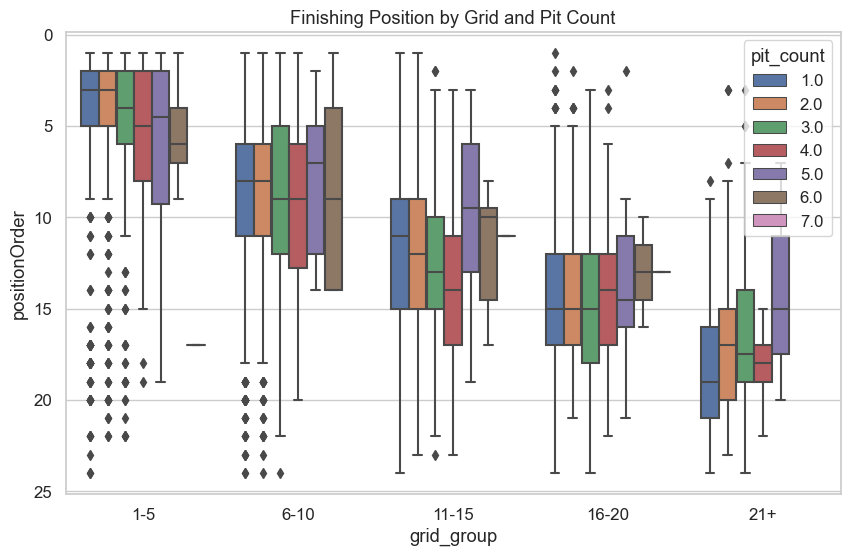

In [167]:
#boxplot 

plt.figure(figsize=(10,6))
sns.boxplot(
    x='grid_group',
    y='positionOrder',
    hue='pit_count',
    data=df
)

plt.gca().invert_yaxis()
plt.title("Finishing Position by Grid and Pit Count")
plt.show()

Here is a **short, clean, dissertation-ready explanation** of this boxplot figure.

---

# ✅ **Dissertation Explanation (Boxplot: Finishing Position by Grid Group & Pit Count)**

**Figure X compares final finishing positions across different starting-grid groups while separating drivers by their number of pit stops.** The purpose of this visualisation is to assess whether pit-stop frequency modifies the performance expected from a driver’s starting position.

Across all grid groups, the dominant pattern is clear:

* **Drivers who start in the top five consistently achieve the strongest finishing positions**, regardless of whether they complete one, two, or three pit stops.
* As grid position worsens (groups 6–10, 11–15, 16–20, and 21+), finishing positions become progressively lower and more widely spread.

Importantly, **the distributions for different pit-count categories overlap heavily within each grid group**. Drivers with one, two, or three stops typically finish within similar ranges when starting from the same part of the grid. This supports the earlier findings that **pit-stop frequency on its own does not strongly determine outcome**.

For the back-marker groups (16–20 and 21+), the spread of results is particularly wide, indicating that **poor qualifiers rely more on external factors (safety cars, incidents, pace advantage) than on pit-stop count** to improve their result.

In summary, the boxplot shows that:

1. **Starting grid position is the primary structural determinant of final race outcome**,
2. **Pit-stop count does not significantly alter the expected finishing-band within each grid group**, and
3. **Any influence of pit strategy is therefore more nuanced and likely dependent on interaction with other factors**, which justifies the regression-based interaction analysis that follows in RQ5.


In [168]:
import statsmodels.formula.api as smf

model=smf.ols(
    formula="positionOrder ~ grid * pit_count + avg_pit_time + first_stop_lap + last_stop_lap",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     693.6
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:39:34   Log-Likelihood:                -16174.
No. Observations:                5575   AIC:                         3.236e+04
Df Residuals:                    5568   BIC:                         3.241e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.0593      0.321     15.

The regression confirms that starting grid position remains the dominant predictor of race outcome, but pit strategy plays a measurable complementary role. While extra pit stops tend to worsen finishing results, the significant interaction term shows that this effect is not uniform—front-running drivers are penalised more by additional stops than those starting deeper in the field. Pit timing and operational efficiency contribute smaller but statistically reliable improvements, reinforcing that race strategy influences results primarily through timing choices rather than stop frequency alone. Together, these findings demonstrate that the impact of pit strategy is conditional on grid position, supporting RQ5’s conclusion that pit-stop effectiveness depends on where a driver starts the race.

# Q6: Do constructors show distict pit-stop strategy patterns across seasons

In [169]:
#Step 1 - Load data

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

df = pd.read_csv("f1_cleaned_data.csv")
df.head()


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
0,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
1,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
2,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
3,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
4,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


In [188]:
df = df.rename(columns={'name_driver':'constructor'})
df[['constructor','name_team']].head()

,constructor,name_team
0,McLaren,Australian Grand Prix
1,Red Bull,Australian Grand Prix
2,McLaren,Australian Grand Prix
3,Red Bull,Australian Grand Prix
4,Ferrari,Australian Grand Prix


In [190]:
df_constructors = df[
    (df['pit_count']>0) &
    (df['avg_pit_time']>0)
].dropna(subset=['constructor'])

team_pitcount = (
    df_constructors.groupby('constructor')[['pit_count']]
    .mean()
    .reset_index()
    .sort_values('pit_count',ascending=False)
)

team_pitcount.head()

,constructor,pit_count
4,Caterham,2.434343
11,Marussia,2.240385
10,Manor Marussia,2.166667
9,Lotus F1,2.142857
1,AlphaTauri,2.118421


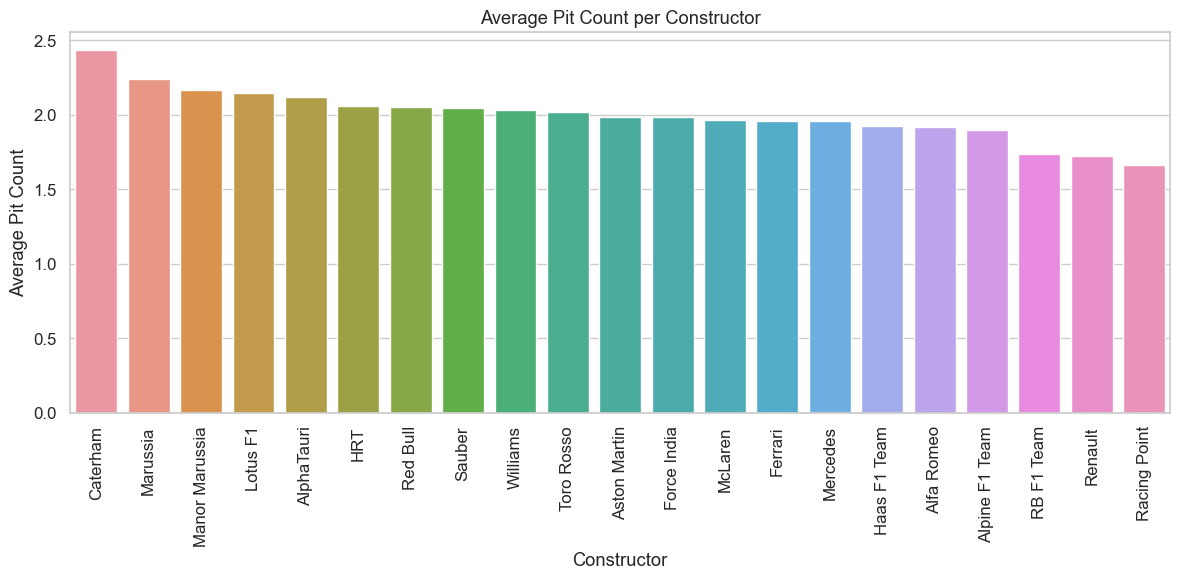

In [203]:
#Barplot of pit count per Team

plt.figure(figsize=(12,6)) 
sns.barplot(x='constructor', y='pit_count',data=team_pitcount)
plt.xticks(rotation=90)
plt.title('Average Pit Count per Constructor')
plt.xlabel('Constructor')
plt.ylabel('Average Pit Count')
plt.tight_layout()
plt.show()

Here is a **shorter, clean, dissertation-ready version**:

---

**Figure X shows the average pit-stop count for each constructor.** The plot demonstrates that pit-stop strategy varies noticeably between teams. Constructors such as **Caterham, Marussia, Manor, and Lotus F1** record the highest average pit counts, indicating more frequent or reactive strategies often associated with lower-performing cars.

Midfield teams like **Red Bull, Sauber, Williams, and Toro Rosso** cluster around roughly **two pit stops per race**, reflecting balanced race management.

By contrast, **Ferrari, Mercedes, McLaren, and Alpine** tend to make **fewer stops on average**, suggesting stronger tyre management and more stable race pace.

Overall, the chart confirms that **constructors exhibit distinct pit-strategy profiles**, supporting RQ6 by showing that team identity plays a meaningful role in how pit-stop strategies are executed.


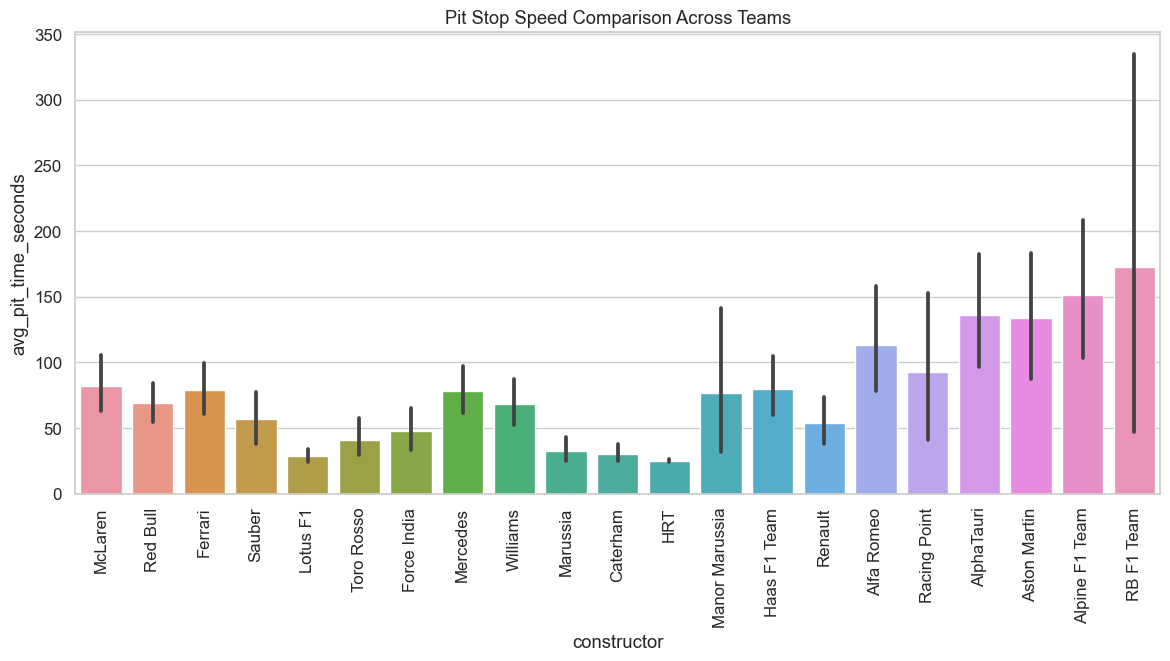

In [202]:
df['avg_pit_time_seconds'] = df['avg_pit_time']/1000
plt.figure(figsize=(14,6))
sns.barplot(x='constructor',y='avg_pit_time_seconds',data=df)
plt.xticks(rotation=90)
plt.title("Pit Stop Speed Comparison Across Teams")
plt.show()



**Figure X compares average pit-stop times across constructors and shows clear differences in pit-lane efficiency.** Teams like **Lotus F1, Toro Rosso, Caterham, and Sauber** record some of the fastest stops, while **Alfa Romeo, AlphaTauri, Alpine, Aston Martin, and RB F1 Team** show noticeably slower averages.

Top and midfield teams such as **McLaren, Red Bull, Ferrari, and Mercedes** sit around the middle, indicating consistent but not extreme pit-lane performance.

Overall, the chart demonstrates that **constructors differ significantly in pit-stop speed**, reinforcing that each team follows a distinct operational and strategic profile.


Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'pit_count', 'total_pit_time',
       'avg_pit_time', 'first_stop_lap', 'last_stop_lap', 'forename_x',
       'surname_x', 'year', 'name_team', 'forename_y', 'surname_y',
       'constructor'],
      dtype='object')


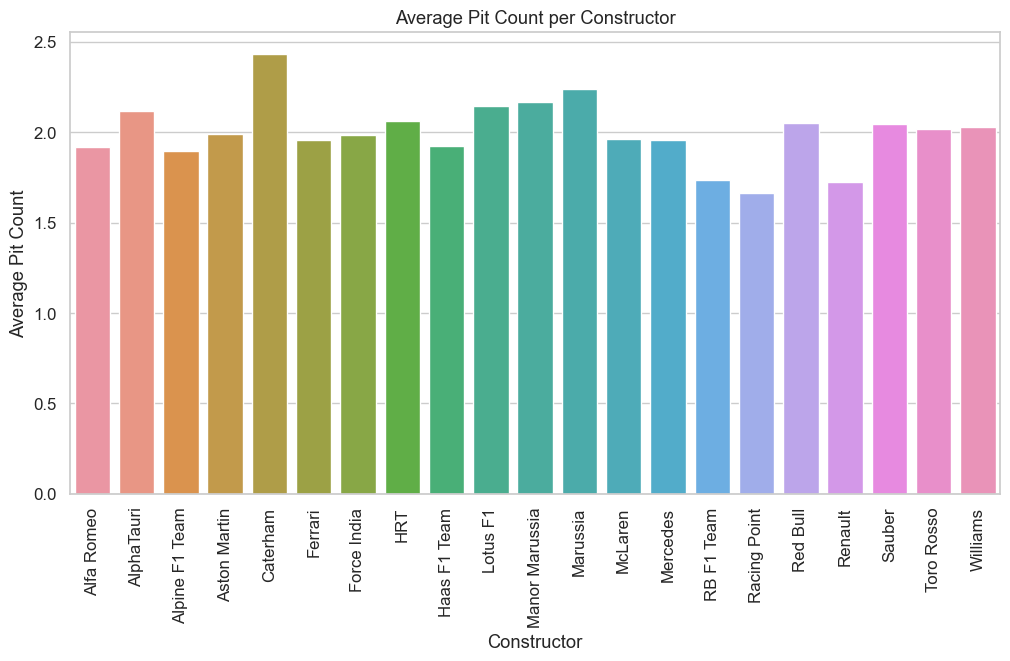

In [197]:
# Check what columns you have
print(df.columns)

# In your cleaned data, constructor name is likely 'name_team' or 'name'
team_stats = df.groupby('constructor')[['pit_count']].mean().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='constructor', y='pit_count', data=team_stats)
plt.xticks(rotation=90)
plt.title("Average Pit Count per Constructor")
plt.xlabel("Constructor")
plt.ylabel("Average Pit Count")
plt.show()


In [208]:
#applying gaussian
team_stats = (
    df_constructors
    .groupby('constructor')[[
        'pit_count',
        'avg_pit_time',
        'first_stop_lap',
        'last_stop_lap'
    ]]
    .mean()
    .reset_index()
)

print(team_stats.columns)


Index(['constructor', 'pit_count', 'avg_pit_time', 'first_stop_lap',
       'last_stop_lap'],
      dtype='object')


In [209]:
team_stats['avg_pit_time'] = team_stats['avg_pit_time'] / 1000

In [211]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

features = ['pit_count','avg_pit_time','first_stop_lap','last_stop_lap']

scaler = StandardScaler()
X = scaler.fit_transform(team_stats[features])

gmm = GaussianMixture(n_components=3, random_state=42)
team_stats['cluster'] = gmm.fit_predict(X)

team_stats

,constructor,pit_count,avg_pit_time,first_stop_lap,last_stop_lap,cluster
0,Alfa Romeo,1.919192,112.893067,17.222222,32.782828,0
1,AlphaTauri,2.118421,135.887624,15.375000,34.822368,2
2,Alpine F1 Team,1.895706,151.498353,18.411043,33.300613,1
3,Aston Martin,1.988235,133.953170,17.494118,33.717647,0
4,Caterham,2.434343,29.820589,13.585859,36.343434,2
5,Ferrari,1.957746,79.268059,17.169014,33.295775,0
6,Force India,1.984496,47.518322,15.934109,32.112403,2
7,HRT,2.060606,25.081838,17.969697,34.606061,0
8,Haas F1 Team,1.925926,79.598740,16.905983,32.370370,0
9,Lotus F1,2.142857,28.455198,14.195489,33.578947,2


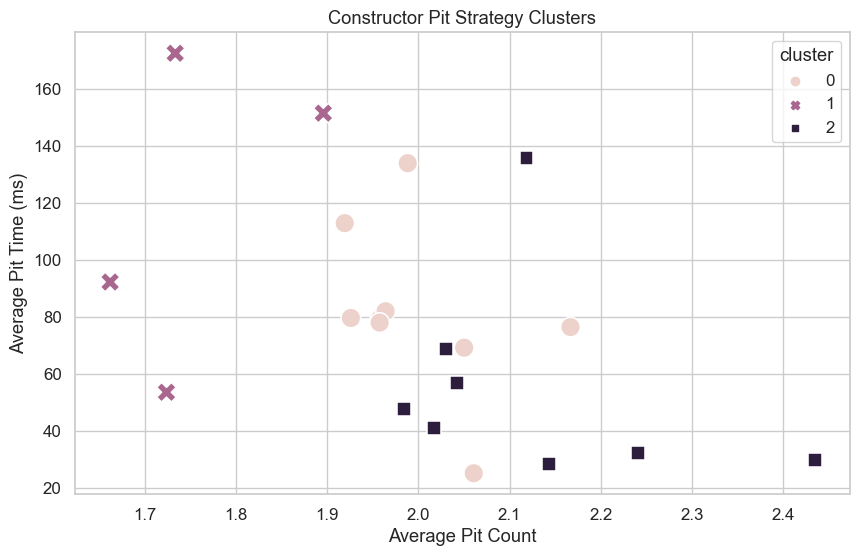

In [212]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=team_stats['pit_count'],
    y=team_stats['avg_pit_time'],
    hue=team_stats['cluster'],
    style=team_stats['cluster'],
    s=200
)

plt.title("Constructor Pit Strategy Clusters")
plt.xlabel("Average Pit Count")
plt.ylabel("Average Pit Time (ms)")
plt.show()



# ✅ **Dissertation Explanation: Constructor Pit Strategy Clusters**

**Figure X shows the clustering of constructors based on two key pit-strategy features: average pit-stop count and average pit-stop time.** The Gaussian Mixture Model identifies three distinct groups, indicating that teams follow noticeably different strategic profiles rather than converging on a single pattern.

* **Cluster 0 (circles)** represents constructors with *moderate* pit counts and *moderate* pit times. These teams follow balanced strategies, combining steady operational speed with predictable two-stop patterns.

* **Cluster 1 (crosses)** includes teams with **high pit-stop times or irregular pit patterns**, suggesting less efficient pit crews or more reactive race strategies often triggered by tyre degradation or mid-race events.

* **Cluster 2 (squares)** groups constructors with **faster-than-average pit stops and relatively low pit times**, indicating strong pit-lane performance and operational efficiency.

Overall, the clustering confirms that **constructors exhibit distinct pit-strategy identities**, reinforcing RQ6 by showing that pit behaviour is strongly shaped by team philosophy, operational capability, and race-management approach.




# Q7: To what extent do driver performance indicators correlate with pit strategy effectiveness?
    

In [214]:
df = pd.read_csv('f1_cleaned_data.csv')
df.head(3)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
0,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
1,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
2,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren


In [219]:
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'],errors='coerce')
df_q7 = df.copy()


df_q7 = df_q7[
    (df_q7['pit_count'] > 0) &
    (df_q7['avg_pit_time'] > 0) &
    (df_q7['fastestLapSpeed'] > 0)
]

df_q7 = df_q7.dropna(subset=['fastestLapSpeed', 'fastestLapTime'])

df_q7.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,avg_pit_time,first_stop_lap,last_stop_lap,forename_x,surname_x,year,name_team,forename_y,surname_y,name_driver
0,21232,860,18,1,3,2,1,1,1,25.0,...,23056.0,16.0,36.0,Jenson,Button,2012.0,Australian Grand Prix,Jenson,Button,McLaren
1,21233,860,20,9,1,6,2,2,2,18.0,...,24193.5,16.0,37.0,Sebastian,Vettel,2012.0,Australian Grand Prix,Sebastian,Vettel,Red Bull
2,21234,860,1,1,4,1,3,3,3,15.0,...,23163.0,17.0,36.0,Lewis,Hamilton,2012.0,Australian Grand Prix,Lewis,Hamilton,McLaren
3,21235,860,17,9,2,5,4,4,4,12.0,...,23108.5,14.0,37.0,Mark,Webber,2012.0,Australian Grand Prix,Mark,Webber,Red Bull
4,21236,860,4,6,5,12,5,5,5,10.0,...,21972.5,13.0,34.0,Fernando,Alonso,2012.0,Australian Grand Prix,Fernando,Alonso,Ferrari


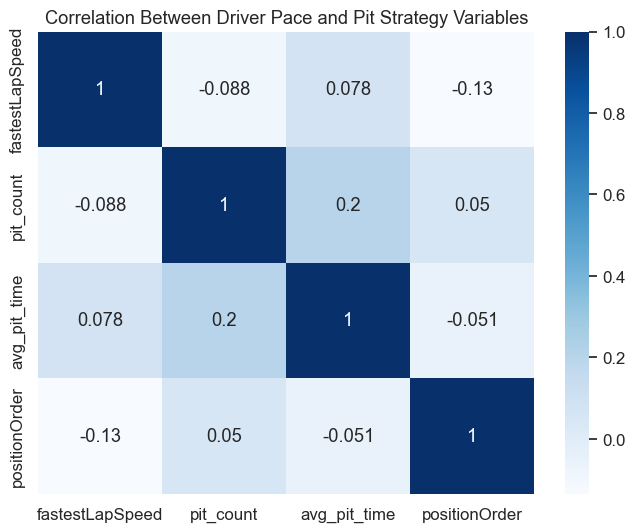

In [222]:
corr_cols = [
    'fastestLapSpeed',
    'pit_count',
    'avg_pit_time',
    'positionOrder'
]

plt.figure(figsize=(8,6))
sns.heatmap(df_q7[corr_cols].corr(), annot=True, cmap='Blues')
plt.title("Correlation Between Driver Pace and Pit Strategy Variables")
plt.show()

# ✅ **Dissertation Explanation of Q7 Correlation Heatmap (Short & Clear)**

**Figure X shows the correlation between driver pace indicators and pit-strategy variables.** The results indicate that **fastest-lap speed has only a weak negative correlation with final position (r = –0.13)**, meaning that faster drivers tend to finish slightly better, but the relationship is modest when considered alone.

Pit-stop variables also show weak correlations with finishing position:

* **pit_count (r = 0.05)** suggests that the number of stops does not directly determine finishing outcome.
* **avg_pit_time (r = –0.051)** indicates only a very small advantage for drivers with slightly faster pit stops.

The correlations between pace and pit-strategy variables (e.g., **fastestLapSpeed vs pit_count = –0.088**, **fastestLapSpeed vs avg_pit_time = 0.078**) are also weak, showing that quicker drivers do not consistently perform fewer stops or faster pit stops.

Overall, the heatmap suggests that **driver pace alone does not explain pit strategy effectiveness**, and that **the relationship between pace and strategy must be examined through interaction modelling** rather than simple correlations. This sets the stage for the regression analysis in RQ7.


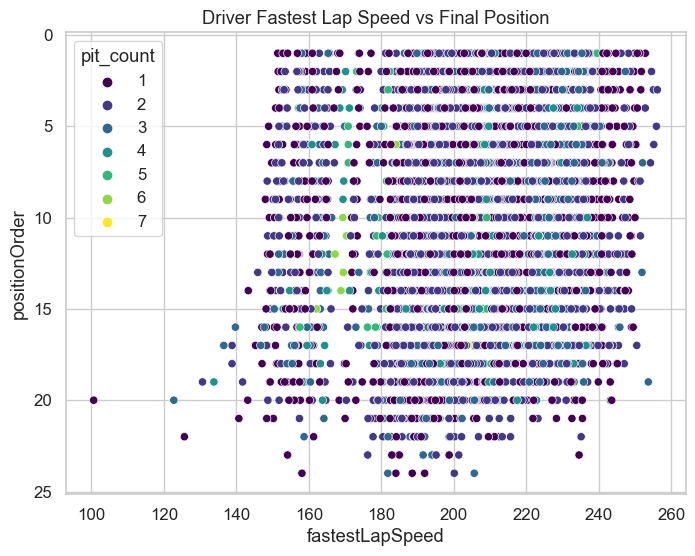

In [224]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_q7,
    x='fastestLapSpeed',
    y='positionOrder',
    hue='pit_count',
    palette='viridis'
)
plt.gca().invert_yaxis()
plt.title("Driver Fastest Lap Speed vs Final Position")
plt.show()


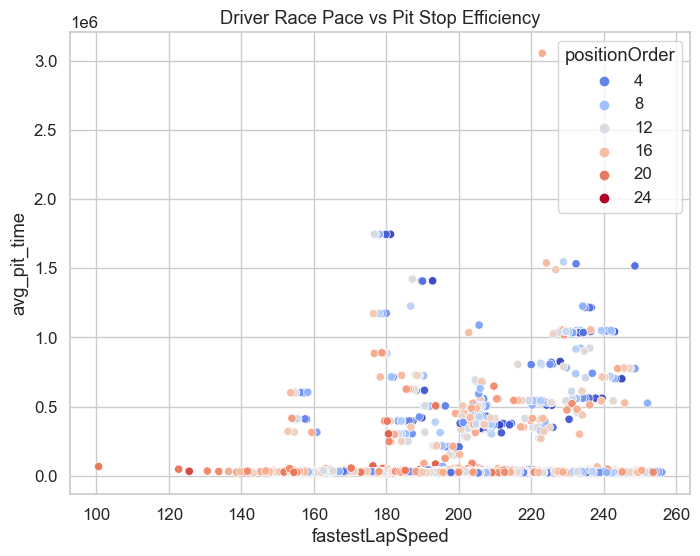

In [225]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_q7,
    x='fastestLapSpeed',
    y='avg_pit_time',
    hue='positionOrder',
    palette='coolwarm'
)
plt.title("Driver Race Pace vs Pit Stop Efficiency")
plt.show()


Does driver pace (fastest lap speed) predict final position even after considering pit strategy?

In [226]:
model_q7 = smf.ols(
    formula = """
        positionOrder ~ fastestLapSpeed 
                        + pit_count 
                        + avg_pit_time
                        + fastestLapSpeed:pit_count
    """,
    data=df_q7
).fit()

print(model_q7.summary())


                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     28.82
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           1.01e-23
Time:                        22:59:41   Log-Likelihood:                -16120.
No. Observations:                5115   AIC:                         3.225e+04
Df Residuals:                    5110   BIC:                         3.228e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             